In [1]:
import pandas as pd
import polars as pl
import numpy as np
import pyarrow as pa
import pyarrow.feather as feather
from datetime import timezone, timedelta, datetime
import os


In [2]:
ls /home/leonmortari/code/phd-ita/projeto_bs-osn/NWSD

Public.xlsx


In [6]:
# -----------------------------
# LEITURA DA BASE DE DADOS E PRÉ-PROCESSAMENTO
# -----------------------------

# Carregamento inicial do DataFrame
df = pd.read_excel(r"/home/leonmortari/code/phd-ita/projeto_bs-osn/NWSD/Public.xlsx")

# 1. LIMPEZA DOS NOMES DAS COLUNAS
df.columns = df.columns.str.strip() 

# 2. LIMPEZA DE WHITESPACE EM TODAS AS COLUNAS DE TEXTO (Tipo 'object')
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.strip()

# 3. CONVERSÃO DE VALORES AUSENTES (AGORA LIMPOS) PARA np.nan
unknown_values = ["Unknown", "UNKNOWN", "unk", "NaN", "nan", "None"] # Removemos "" e " "
# NOTE: O str.strip() já cuida de " " e "", então a lista é reduzida.
df = df.replace(unknown_values, np.nan)

# 4. TRATAMENTO DE STRINGS VAZIAS REMANESCENTES
# Após o strip, se houver células que ficaram vazias, converte-as para NaN.
df = df.replace("", np.nan)

# 5. FILTRO FINAL: REMOVE LINHAS ONDE COLUNAS CRÍTICAS SÃO NaN
df = df.dropna(subset=['TIME', 'INCIDENT_DATE'])

# 6. CONSTRUÇÃO FINAL DO TIMESTAMP (Mantendo a sua lógica de concatenação)
df["INCIDENT_DATE"] = pd.to_datetime(df["INCIDENT_DATE"])

# Formata a coluna TIME para HH:MM:SS (assumindo que TIME é HH)

df['TIMESTAMP_STR'] = df['INCIDENT_DATE'].astype(str) + ' ' + (df['TIME']+':00').astype(str)

# CONVERSÃO PARA DATETIME E DEPOIS PARA NUMÉRICO (EPOCH/UNIX)

df['DATETIME_UTC'] = pd.to_datetime(df['TIMESTAMP_STR']).dt.tz_localize(timezone.utc)

# Segundo, para um valor numérico (Unix Timestamp em segundos)
# O Pandas armazena internamente em nanosegundos (10^9). Dividimos por 10^9.
df['TIMESTAMP_UNIX_SEC'] = (df['DATETIME_UTC'].astype(np.int64) // 10**9)

print("\nValores convertidos:")
print(df[['TIMESTAMP_STR', 'DATETIME_UTC', 'TIMESTAMP_UNIX_SEC']].head())


Valores convertidos:
           TIMESTAMP_STR              DATETIME_UTC  TIMESTAMP_UNIX_SEC
9    1990-08-07 20:25:00 1990-08-07 20:25:00+00:00           650060700
43   1990-08-05 19:05:00 1990-08-05 19:05:00+00:00           649883100
117  1991-04-17 13:15:00 1991-04-17 13:15:00+00:00           671894100
131  1990-10-15 10:07:00 1990-10-15 10:07:00+00:00           655985220
139  1990-09-21 10:00:00 1990-09-21 10:00:00+00:00           653911200


In [7]:
#APENAS COLUNAS DE INTERESSE
df = df[[
    "DATETIME_UTC","TIMESTAMP_UNIX_SEC","INCIDENT_DATE", "TIME", "TIME_OF_DAY", "AIRPORT_ID",
    "AIRPORT", "RUNWAY", "AIRCRAFT", "PHASE_OF_FLIGHT",
    "HEIGHT", "SKY", "OPERATOR", "OPID", "REG", "FLT",
    "SPECIES", "SIZE"
]]

print("Tipos de dados por coluna:")
print(df.dtypes)

Tipos de dados por coluna:
DATETIME_UTC          datetime64[ns, UTC]
TIMESTAMP_UNIX_SEC                  int64
INCIDENT_DATE              datetime64[ns]
TIME                               object
TIME_OF_DAY                        object
AIRPORT_ID                         object
AIRPORT                            object
RUNWAY                             object
AIRCRAFT                           object
PHASE_OF_FLIGHT                    object
HEIGHT                            float64
SKY                                object
OPERATOR                           object
OPID                               object
REG                                object
FLT                                object
SPECIES                            object
SIZE                               object
dtype: object


In [5]:
df.head(5)

,DATETIME_UTC,TIMESTAMP_UNIX_SEC,INCIDENT_DATE,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,RUNWAY,AIRCRAFT,PHASE_OF_FLIGHT,HEIGHT,SKY,OPERATOR,OPID,REG,FLT,SPECIES,SIZE
9,1990-08-07 20:25:00+00:00,650060700,1990-08-07,20:25,Night,KSTL,LAMBERT-ST LOUIS INTL,NaN,C-152,Climb,200.0,No Cloud,PRIVATELY OWNED,PVT,NaN,NaN,Unknown bird - large,Large
43,1990-08-05 19:05:00+00:00,649883100,1990-08-05,19:05,Day,KBWI,BALTIMORE/WASH INTL THURGOOD MARSHAL ARPT,NaN,FOKKER F28 MK 1000,Landing Roll,0.0,Some Cloud,1US AIRWAYS,USA,NaN,NaN,Unknown bird - small,Small
118,1991-04-17 13:15:00+00:00,671894100,1991-04-17,13:15,Day,KDCA,RONALD REAGAN WASHINGTON NATIONAL ARPT,NaN,B-727,Climb,100.0,No Cloud,AMERICAN AIRLINES,AAL,NaN,NaN,Ring-billed gull,Medium
132,1990-10-15 10:07:00+00:00,655985220,1990-10-15,10:07,Night,KTRI,TRI-CITIES REGIONAL TN/VA ARPT,23,MERLIN IV,Approach,1500.0,No Cloud,NASHVILLE EAGLE,NAE,NaN,NaN,Unknown bird - medium,Medium
140,1990-09-21 10:00:00+00:00,653911200,1990-09-21,10:00,Day,KMWH,GRANT COUNTY ARPT,32,B-747-1/200,Climb,3000.0,No Cloud,JAPAN AIRLINES,JAL,JA8104,NaN,Swallows,Small


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 187794 entries, 9 to 329595
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   DATETIME_UTC        187794 non-null  datetime64[ns, UTC]
 1   TIMESTAMP_UNIX_SEC  187794 non-null  int64              
 2   INCIDENT_DATE       187794 non-null  datetime64[ns]     
 3   TIME                187794 non-null  object             
 4   TIME_OF_DAY         149383 non-null  object             
 5   AIRPORT_ID          187794 non-null  object             
 6   AIRPORT             171187 non-null  object             
 7   RUNWAY              153402 non-null  object             
 8   AIRCRAFT            163601 non-null  object             
 9   PHASE_OF_FLIGHT     152622 non-null  object             
 10  HEIGHT              125504 non-null  float64            
 11  SKY                 119825 non-null  object             
 12  OPERATOR            1

Dawn NaN count 0
Day NaN count 0
Dusk NaN count 0
Night NaN count 0


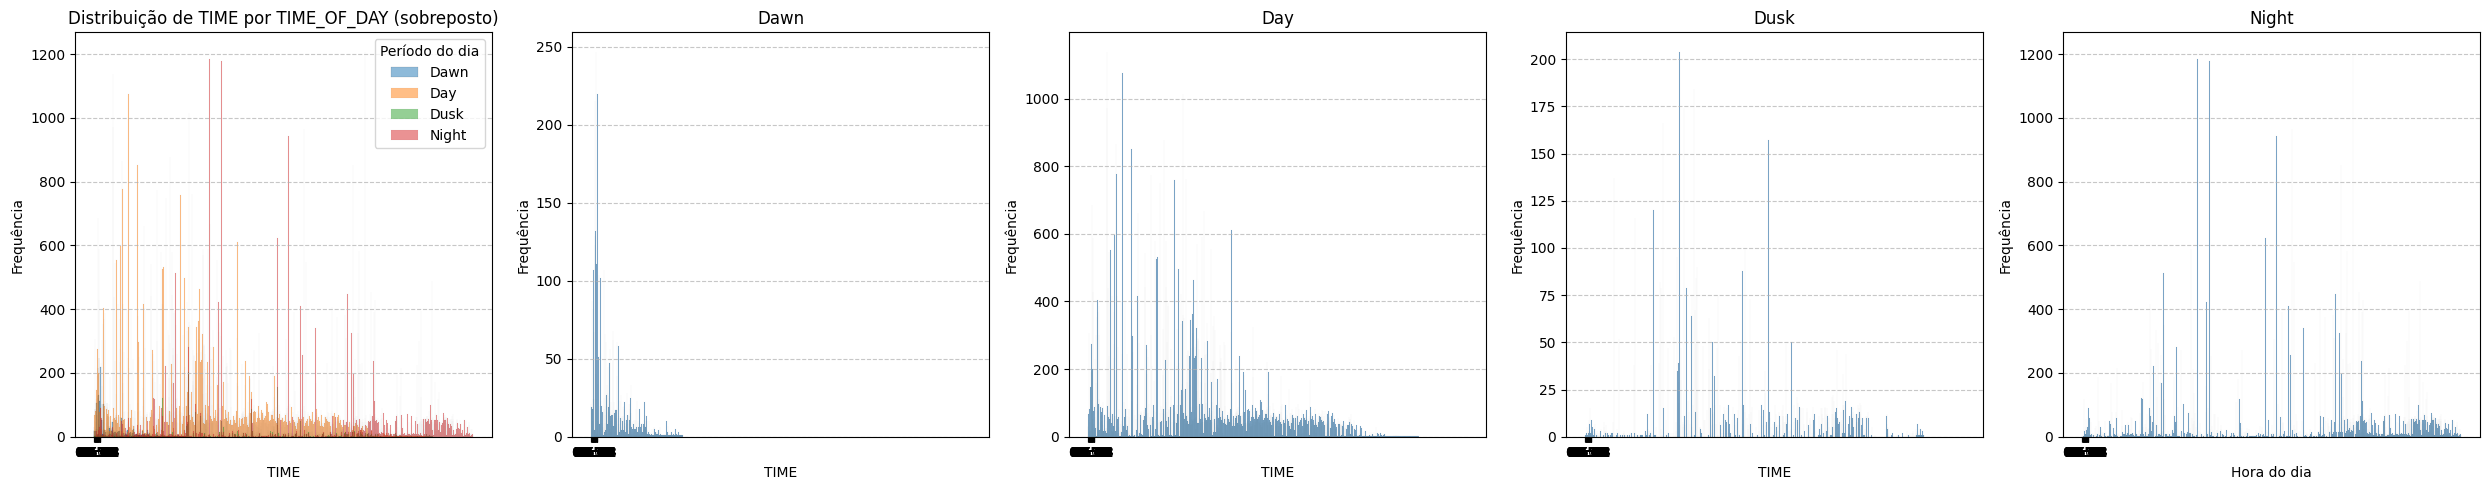

In [18]:
# -----------------------------
# ANALISE: TIME OF DAY
# -----------------------------

import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(25, 5), sharex=True)

# --- Subplot 1: histograma combinado ---
ax0 = axes[0]
for label, group in df.groupby('TIME_OF_DAY'):
    print(f"{label} NaN count {group['TIME'].isna().sum()}")
    sns.histplot(group['TIME'],
             bins=24,
             alpha=0.5,
             label=label,
             ax=ax0)

ax0.set_title('Distribuição de TIME por TIME_OF_DAY (sobreposto)')
ax0.set_ylabel('Frequência')
ax0.legend(title='Período do dia')
ax0.grid(axis='y', linestyle='--', alpha=0.7)

# --- Subplots individuais ---
for ax, (label, group) in zip(axes[1:], df.groupby('TIME_OF_DAY')):
    sns.histplot(group['TIME'], bins=24, color='steelblue', alpha=0.7,ax=ax)
    ax.set_title(f'{label}')
    ax.set_ylabel('Frequência')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

axes[-1].set_xlabel('Hora do dia')
plt.xticks(range(0, 25))
plt.tight_layout()
plt.show()


NaN count 0


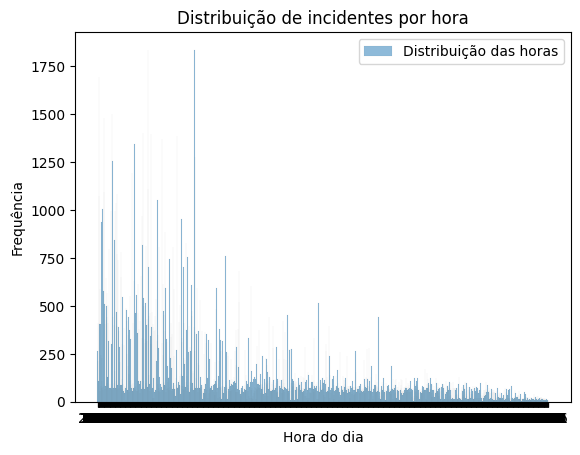

In [19]:
# MAIOR FREQUENCIA DE HORA

print(f"NaN count {df['TIME'].isna().sum()}")

plt.figure()

sns.histplot(
    df['TIME'],
    bins=24,
    alpha=0.5,
    label='Distribuição das horas'
)

plt.xlabel("Hora do dia")
plt.ylabel("Frequência")
plt.title("Distribuição de incidentes por hora")
plt.legend()
plt.show()


In [7]:
(df.isna().sum())

DATETIME_UTC              0
TIMESTAMP_UNIX_SEC        0
INCIDENT_DATE             0
TIME                      0
TIME_OF_DAY           38411
AIRPORT_ID                0
AIRPORT               16607
RUNWAY                34392
AIRCRAFT              24193
PHASE_OF_FLIGHT       35172
HEIGHT                62290
SKY                   67969
OPERATOR              23816
OPID                      2
REG                   45624
FLT                   62874
SPECIES                   1
SIZE                  27114
dtype: int64

In [20]:
# -----------------------------
# FUNÇÃO PARA DETERMINAR ESTAÇÃO (HEMISFÉRIO NORTE) - MANTIDA
# -----------------------------
def get_season(date):
    if pd.isna(date):
        return None
    
    month = date.month
    day = date.day

    # Verão (Summer: 21 Jun – 22 Sep)
    if (month == 6 and day >= 21) or (month in [7, 8]) or (month == 9 and day < 23):
        return "Summer"
    
    # Outono (Fall: 23 Sep – 21 Dec)
    elif (month == 9 and day >= 23) or (month in [10, 11]) or (month == 12 and day < 22):
        return "Fall"
    
    # Inverno (Winter: 22 Dec – 19 Mar)
    elif (month == 12 and day >= 22) or (month in [1, 2]) or (month == 3 and day < 20):
        return "Winter"
    
    # Primavera (Spring: 20 Mar – 20 Jun)
    elif (month == 3 and day >= 20) or (month in [4, 5]) or (month == 6 and day < 21):
        return "Spring"
    
    return None

# Aplicar função ao DataFrame
# Nota: A coluna "INCIDENT_DATE" deve ser datetime para este apply funcionar.
df["SEASON"] = df["INCIDENT_DATE"].apply(get_season)


# -----------------------------
# PERÍODO DO DIA - AJUSTE (CÓDIGO CORRIGIDO PARA EVITAR ValueError)
# -----------------------------

# 1. FUNÇÃO PARA DERIVAR PERÍODO DO DIA (Não alterada)
def derive_time_of_day(hour):
    if pd.isna(hour):
        return None
        
    h = int(hour)
    if 0 <= h <= 5:   return "Night"
    if 6 <= h <= 7:   return "Dawn"
    if 8 <= h <= 17:  return "Day"
    if 18 <= h <= 19: return "Dusk"
    if 20 <= h <= 23: return "Night"
    return None

# 2. FLUXO CORRIGIDO PARA EXTRAIR HORAS SEM ERRO:
# Converte a coluna 'TIME' (que pode ser float, int ou string HH:MM) para hora numérica.

# Identifica linhas não-nulas na coluna TIME
time_not_na = ~df["TIME"].isna()

# Converte TIME para um formato de datetime para EXTRAIR A HORA
# O errors='coerce' é CRÍTICO para lidar com valores como 13.0 (float) ou '13:00' (string)
df.loc[time_not_na, 'TEMP_HOUR'] = pd.to_datetime(
    df.loc[time_not_na, 'TIME'].astype(str), 
    format='%H:%M', 
    errors='coerce'
).dt.hour

# Se a coluna TIME original for Float (ex: 13.0), o to_datetime com format='%H:%M' falhará.
# Usamos o método mais robusto: assumir que se falhar a conversão de string, é a hora decimal.
time_is_nan = df['TEMP_HOUR'].isna() & time_not_na

# Se falhou a conversão de string, tentamos ler como o valor inteiro da hora (13.0 -> 13)
df.loc[time_is_nan, 'TEMP_HOUR'] = df.loc[time_is_nan, 'TIME'].apply(
    lambda x: int(x) if isinstance(x, (float, int)) else None
)


# 3. APLICAÇÃO DA FUNÇÃO
print(f"Not NaN count {(~df.get('TIME_OF_DAY', pd.Series()).isna()).sum()} before")
df.loc[time_not_na, 'TIME_OF_DAY'] = df.loc[time_not_na, 'TEMP_HOUR'].apply(derive_time_of_day)

print(f"Not NaN count {(~df['TIME_OF_DAY'].isna()).sum()} after")

# 4. LIMPEZA
df = df.drop(columns=['TEMP_HOUR'], errors='ignore')

df.head()

Not NaN count 149383 before
Not NaN count 187794 after


/tmp/ipykernel_3432014/3564639203.py:70: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[time_is_nan, 'TEMP_HOUR'] = df.loc[time_is_nan, 'TIME'].apply(


,DATETIME_UTC,TIMESTAMP_UNIX_SEC,INCIDENT_DATE,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,RUNWAY,AIRCRAFT,PHASE_OF_FLIGHT,HEIGHT,SKY,OPERATOR,OPID,REG,FLT,SPECIES,SIZE,SEASON
9,1990-08-07 20:25:00+00:00,650060700,1990-08-07,20:25,Night,KSTL,LAMBERT-ST LOUIS INTL,NaN,C-152,Climb,200.0,No Cloud,PRIVATELY OWNED,PVT,NaN,NaN,Unknown bird - large,Large,Summer
43,1990-08-05 19:05:00+00:00,649883100,1990-08-05,19:05,Dusk,KBWI,BALTIMORE/WASH INTL THURGOOD MARSHAL ARPT,NaN,FOKKER F28 MK 1000,Landing Roll,0.0,Some Cloud,1US AIRWAYS,USA,NaN,NaN,Unknown bird - small,Small,Summer
118,1991-04-17 13:15:00+00:00,671894100,1991-04-17,13:15,Day,KDCA,RONALD REAGAN WASHINGTON NATIONAL ARPT,NaN,B-727,Climb,100.0,No Cloud,AMERICAN AIRLINES,AAL,NaN,NaN,Ring-billed gull,Medium,Spring
132,1990-10-15 10:07:00+00:00,655985220,1990-10-15,10:07,Day,KTRI,TRI-CITIES REGIONAL TN/VA ARPT,23,MERLIN IV,Approach,1500.0,No Cloud,NASHVILLE EAGLE,NAE,NaN,NaN,Unknown bird - medium,Medium,Fall
140,1990-09-21 10:00:00+00:00,653911200,1990-09-21,10:00,Day,KMWH,GRANT COUNTY ARPT,32,B-747-1/200,Climb,3000.0,No Cloud,JAPAN AIRLINES,JAL,JA8104,NaN,Swallows,Small,Summer


Dawn NaN count 0
Day NaN count 0
Dusk NaN count 0
Night NaN count 0


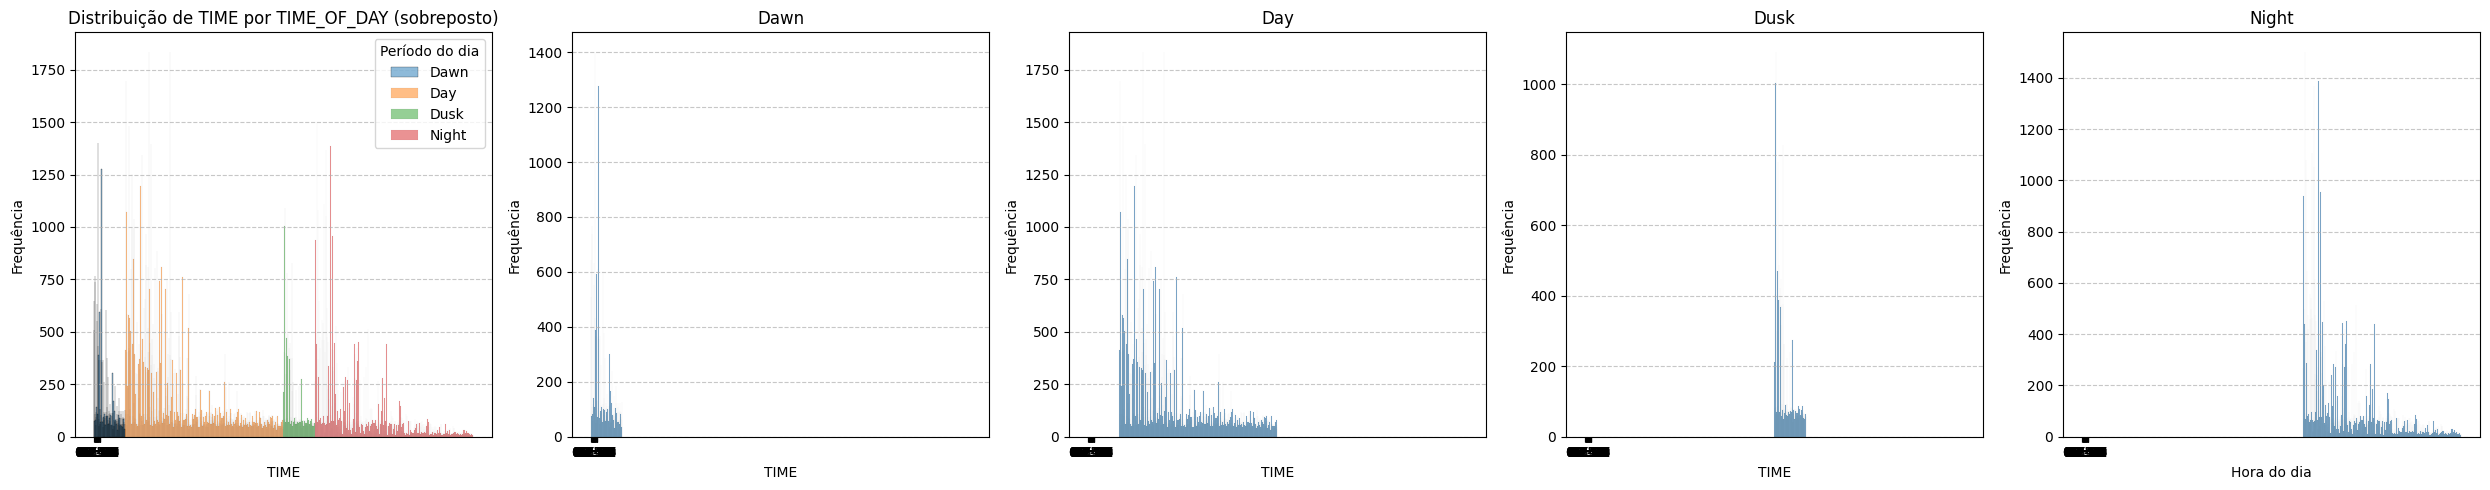

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(25, 5), sharex=True)

# --- Subplot 1: histograma combinado ---
ax0 = axes[0]
for label, group in df.groupby('TIME_OF_DAY'):
    print(f"{label} NaN count {group['TIME'].isna().sum()}")
    sns.histplot(group['TIME'],
             bins=24,
             alpha=0.5,
             label=label,
             ax=ax0)

ax0.set_title('Distribuição de TIME por TIME_OF_DAY (sobreposto)')
ax0.set_ylabel('Frequência')
ax0.legend(title='Período do dia')
ax0.grid(axis='y', linestyle='--', alpha=0.7)

# --- Subplots individuais ---
for ax, (label, group) in zip(axes[1:], df.groupby('TIME_OF_DAY')):
    sns.histplot(group['TIME'], bins=24, color='steelblue', alpha=0.7,ax=ax)
    ax.set_title(f'{label}')
    ax.set_ylabel('Frequência')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

axes[-1].set_xlabel('Hora do dia')
plt.xticks(range(0, 25))
plt.tight_layout()
plt.show()


In [22]:
# -----------------------------
# AJUSTE DOS DADOS - LIMPEZA DADOS FALTANTES
# -----------------------------

# 1. PADRONIZAÇÃO DOS DADOS FALTANTES
unknown_values = ["Unknown", "UNKNOWN", "unk", "NaN", "nan", "None", "", " "]
df = df.replace(unknown_values, np.nan)

# 2.LIMPEZA DOS DADOS FALTANTES CRÍTICOS
df = df.dropna(subset=["INCIDENT_DATE", "TIME","FLT","OPID" ])

# 3. NOVO DATAFRAME
data_strike = df[["DATETIME_UTC","TIMESTAMP_UNIX_SEC","INCIDENT_DATE","SEASON","TIME","TIME_OF_DAY","AIRPORT_ID",
                  "AIRPORT","RUNWAY", "AIRCRAFT","PHASE_OF_FLIGHT", 
                  "HEIGHT", "SKY","OPERATOR","OPID","REG","FLT", "SPECIES", "SIZE"]].copy()

# 4. RESETA O INDEX
data_strike = data_strike.reset_index(drop=True)

data_strike

,DATETIME_UTC,TIMESTAMP_UNIX_SEC,INCIDENT_DATE,SEASON,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,RUNWAY,AIRCRAFT,PHASE_OF_FLIGHT,HEIGHT,SKY,OPERATOR,OPID,REG,FLT,SPECIES,SIZE
0,1997-11-22 15:20:00+00:00,880212000,1997-11-22,Fall,15:20,Day,KMCO,ORLANDO INTL,17R,B-737-200,Landing Roll,0.0,NaN,DELTA AIR LINES,DAL,NaN,2437,Bald eagle,Large
1,1997-12-10 06:45:00+00:00,881736300,1997-12-10,Fall,06:45,Dawn,KCLT,CHARLOTTE/DOUGLAS INTL ARPT,18R,DC-9-50,Take-off Run,0.0,Overcast,NORTHWEST AIRLINES,NWA,N781NC,1579,Mourning dove,Small
2,1998-10-09 20:35:00+00:00,907965300,1998-10-09,Fall,20:35,Night,KPIT,PITTSBURGH INTL ARPT,28,DC-9-30,Take-off Run,0.0,Overcast,1US AIRWAYS,USA,N955VJ,426,Owls,Medium
3,1999-02-03 10:45:00+00:00,918038700,1999-02-03,Winter,10:45,Day,KSLC,SALT LAKE CITY INTL,17,B-737-300,Take-off Run,0.0,No Cloud,SOUTHWEST AIRLINES,SWA,N350SW,1468,Horned lark,Small
4,1997-09-27 11:00:00+00:00,875358000,1997-09-27,Fall,11:00,Day,KJFK,JOHN F KENNEDY INTL,4R,B-767-200,Landing Roll,0.0,No Cloud,AMERICAN AIRLINES,AAL,N323AA,115,Tree swallow,Small
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124913,2025-07-15 17:15:00+00:00,1752599700,2025-07-15,Summer,17:15,Day,KMCO,ORLANDO INTL,18R,B-757-300,Landing Roll,0.0,Some Cloud,DELTA AIR LINES,DAL,N594NW,2225,Mourning dove,Small
124914,2025-04-11 21:17:00+00:00,1744406220,2025-04-11,Spring,21:17,Night,KCID,THE EASTERN IOWA ARPT,NaN,A-319,Approach,NaN,NaN,UNITED AIRLINES,UAL,N829UA,2296,Unknown bird,NaN
124915,2025-04-11 13:02:00+00:00,1744376520,2025-04-11,Spring,13:02,Day,TJSJ,LUIS MUNOZ MARIN INTL,10,A-320,Approach,550.0,NaN,FRONTIER AIRLINES,FFT,N624FR,1824,Unknown bird,NaN
124916,2025-06-20 22:45:00+00:00,1750459500,2025-06-20,Spring,22:45,Night,KSEA,SEATTLE-TACOMA INTL,16R,B-737-900,Descent,NaN,No Cloud,ALASKA AIRLINES,ASA,N281AK,1065,American barn owl,Medium


In [15]:
data_strike.isna().sum()

DATETIME_UTC              0
TIMESTAMP_UNIX_SEC        0
INCIDENT_DATE             0
SEASON                    0
TIME                      0
TIME_OF_DAY               0
AIRPORT_ID                0
AIRPORT               11536
RUNWAY                23288
AIRCRAFT                177
PHASE_OF_FLIGHT       10842
HEIGHT                31683
SKY                   36956
OPERATOR                100
OPID                      0
REG                   16800
FLT                       0
SPECIES                   1
SIZE                  22215
dtype: int64

In [23]:
# -----------------------------
# AJUSTE DOS DADOS - UNIFORMIZA DADOS
# -----------------------------

# Uniformiza o formato da data
data_strike.loc[:, "INCIDENT_DATE"] = pd.to_datetime(data_strike["INCIDENT_DATE"]).dt.strftime("%Y-%m-%d")

# A correção está aqui: pd.to_datetime com errors='coerce' converte valores inválidos para NaT.
# Em seguida, .fillna() substitui esses NaT por um valor de tempo padrão ('00:00').
# data_strike.loc[:, "TIME"] = pd.to_datetime(data_strike["TIME"], format="%H:%M", errors="coerce").fillna(pd.to_datetime('00:00', format='%H:%M')).dt.strftime("%H:%M:%S")

# Uniformiza strings
data_strike.loc[:, "REG"] = data_strike["REG"].astype(str).str.upper().str.strip()
data_strike.loc[:, "OPID"] = data_strike["OPID"].astype(str).str.strip()

# Converte FLT para tipo numérico e remove os decimais
data_strike.loc[:, "FLT"] = pd.to_numeric(data_strike["FLT"], errors='coerce').fillna(0).astype(int).astype(str).str.strip()

# Cria a coluna CALLSIGN concatenando OPID + FLT
data_strike.loc[:, "CALLSIGN"] = data_strike["OPID"] + data_strike["FLT"]

data_strike.head(3)

,DATETIME_UTC,TIMESTAMP_UNIX_SEC,INCIDENT_DATE,SEASON,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,RUNWAY,AIRCRAFT,PHASE_OF_FLIGHT,HEIGHT,SKY,OPERATOR,OPID,REG,FLT,SPECIES,SIZE,CALLSIGN
0,1997-11-22 15:20:00+00:00,880212000,1997-11-22,Fall,15:20,Day,KMCO,ORLANDO INTL,17R,B-737-200,Landing Roll,0.0,NaN,DELTA AIR LINES,DAL,NAN,2437,Bald eagle,Large,DAL2437
1,1997-12-10 06:45:00+00:00,881736300,1997-12-10,Fall,06:45,Dawn,KCLT,CHARLOTTE/DOUGLAS INTL ARPT,18R,DC-9-50,Take-off Run,0.0,Overcast,NORTHWEST AIRLINES,NWA,N781NC,1579,Mourning dove,Small,NWA1579
2,1998-10-09 20:35:00+00:00,907965300,1998-10-09,Fall,20:35,Night,KPIT,PITTSBURGH INTL ARPT,28,DC-9-30,Take-off Run,0.0,Overcast,1US AIRWAYS,USA,N955VJ,426,Owls,Medium,USA426


In [34]:
# -----------------------------
# CLASSIFICAÇÃO DE ESPÉCIES
# -----------------------------

# Mapeamento para agrupar espécies semelhantes (atualizado com a lista extensa)
species_mapping = {
    "Waterfowl (Ducks, Geese, Swans)": [
        "duck", "teal", "wigeon", "scoter", "eider", "goldeneye", "goose", "swan", "brant",
        "cackling goose", "pintail", "merganser", "mallard", "redhead", "northern shoveler",
        "mottled duck", "gadwall", "muscovy duck", "american wigeon", "american black duck",
        "canvasback", "greater white-fronted goose", "lesser scaup", "ring-necked duck",
        "common goldeneye", "long-tailed duck", "bufflehead", "surf scoter", "black-bellied whistling-duck",
        "barrow's goldeneye", "greater scaup", "cinnamon teal", "hawaiian duck", "diving duck (aythya)",
        "snow goose"
    ],
    "Raptor & Owl": [
        "hawk", "kestrel", "falcon", "vulture", "eagle", "osprey", "harrier", "merlin", "caracara",
        "buzzard", "owl", "screech-owl", "kite", "peregrine falcon", "red-tailed hawk",
        "american kestrel", "bald eagle", "turkey vulture", "great horned owl", "swainson's hawk",
        "red-shouldered hawk", "northern harrier", "cooper's hawk", "prairie falcon", "crested caracara",
        "northern hawk owl", "sharp-shinned hawk", "ferruginous hawk", "golden eagle", "mississippi kite",
        "harris's hawk", "eurasian buzzard", "great gray owl", "gyrfalcon"
    ],
    "Wader & Heron": [
        "sandpiper", "plover", "snipe", "dowitcher", "turnstone", "godwit", "stilt", "avocet",
        "phalarope", "curlew", "ibis", "spoonbill", "willet", "shorebird", "heron", "egret",
        "bittern", "cormorant", "pelican", "loon", "grebe", "oystercatcher", "stork", "gallinule",
        "crane", "killdeer", "pacific golden-plover", "western cattle egret", "american coot",
        "great blue heron", "sandhill crane", "black-bellied plover", "upland sandpiper",
        "western sandpiper", "american bittern", "california gull", "western gull",
        "american golden-plover", "black-crowned night heron", "least sandpiper",
        "double-crested cormorant", "semipalmated plover", "lesser yellowlegs", "snowy egret",
        "wilson's snipe", "dunlin", "semipalmated sandpiper", "great egret", "green heron",
        "wood stork", "sanderling", "long-billed dowitcher", "pectoral sandpiper", "pied-billed grebe",
        "common loon", "anhinga", "yellow-crowned night heron", "whooping crane", "whimbrel",
        "red knot", "short-billed dowitcher", "red-throated loon", "black-necked stilt",
        "greater yellowlegs", "american avocet", "spotted sandpiper", "least bittern", "sora",
        "wilson's plover", "piping plover", "red-necked phalarope", "wilson's phalarope",
        "long-billed curlew", "ruddy turnstone", "red-necked grebe",
        "brandt's cormorant", "white-faced ibis", "marbled godwit", "glossy ibis", "roseate spoonbill",
        "black skimmer", "tricolored heron", "forster's tern", "connecticut warbler", "eurasian collared dove"
    ],
    "Gull & Tern": [
        "gull", "tern", "noddy", "kittiwake", "ring-billed gull", "herring gull", "laughing gull",
        "short-billed gull", "heermann's gull", "bonaparte's gull", "caspian tern", "franklin's gull",
        "great black-backed gull", "glaucous-winged gull", "lesser black-backed gull", "common tern",
        "least tern", "sooty tern", "royal tern", "elegant tern"
    ],
    "Passerine & Small Bird": [
        "sparrow", "swallow", "robin", "starling", "lark", "kingfisher", "wren", "thrush", "pipit",
        "grosbeak", "bunting", "crow", "raven", "mockingbird", "grackle", "jay", "magpie",
        "oriole", "woodpecker", "flycatcher", "vireo", "tanager", "chat", "cardinal", "finch",
        "nuthatch", "hummingbird", "parakeet", "parrot", "canary", "drongo", "myna", "waxwing",
        "chickadee", "warbler", "swift", "western meadowlark", "american robin", "blackbird",
        "savannah sparrow", "american crow", "horned lark", "purple martin", "northern mockingbird",
        "snow bunting", "eastern meadowlark", "brown-headed cowbird", "bank swallow", "common yellowthroat",
        "common raven", "black-and-white warbler", "common grackle", "great-tailed grackle",
        "hairy woodpecker", "scissor-tailed flycatcher", "red-vented bulbul", "common myna",
        "fox sparrow", "american pipit", "acadian flycatcher", "song sparrow", "western bluebird",
        "american goldfinch", "yellow-billed magpie", "dark-eyed junco", "cedar waxwing",
        "western kingbird", "blue jay", "brewer's blackbird", "black-billed magpie", "eastern kingbird",
        "lark bunting", "house sparrow", "swainson's thrush", "varied thrush", "hermit thrush",
        "blackpoll warbler", "yellow warbler", "yellow-rumped warbler", "eastern phoebe",
        "lapland longspur", "pine warbler", "northern rough-winged swallow", "orchard oriole",
        "mountain chickadee", "chestnut-collared longspur", "ovenbird", "northern flicker",
        "brown thrasher", "ruby-throated hummingbird", "chipping sparrow", "golden-crowned kinglet",
        "grasshopper sparrow", "bohemian waxwing", "wilson's warbler", "loggerhead shrike",
        "american tree sparrow", "lincoln's sparrow", "field sparrow", "gray catbird",
        "blue-gray gnatcatcher", "vesper sparrow", "eurasian skylark", "white-throated swift",
        "anna's hummingbird", "pine siskin", "western tanager", "bell's sparrow", "mountain bluebird",
        "boat-tailed grackle", "northern parula", "bobolink", "california towhee", "cactus wren",
        "tropical mockingbird", "cave swallow", "ruby-crowned kinglet", "broad-winged hawk",
        "carolina chickadee", "swamp sparrow", "northern house wren", "white-crowned sparrow",
        "indian silverbill", "lesser goldfinch", "western flycatcher", "lark sparrow", "veery",
        "cassin's vireo", "yellow-headed blackbird", "yellow-billed cuckoo", "gray-cheeked thrush",
        "purple finch", "nelson's sparrow", "japanese white-eye", "tennessee warbler",
        "blackburnian warbler", "orange-crowned warbler", "baltimore oriole", "black drongo",
        "bushtit", "black-throated blue warbler", "red-eyed vireo", "canada warbler", "pine grosbeak",
        "black-throated green warbler", "yellow-breasted chat", "warbling vireo", "magnolia warbler",
        "northern waterthrush", "brewer's sparrow", "black-headed grosbeak", "eastern whip-poor-will",
        "dickcissel", "willow flycatcher", "rose-breasted grosbeak", "yellow-throated warbler",
        "american redstart", "cape may warbler", "marsh wren", "sprague's pipit", "indigo bunting",
        "palm warbler", "harris's sparrow", "prairie warbler", "eastern bluebird", "green-tailed towhee",
        "mourning warbler", "black-billed cuckoo", "kentucky warbler", "smith's longspur",
        "carolina wren", "eastern wood-pewee", "yellow-bellied flycatcher", "summer tanager",
        "scarlet tanager", "chestnut-sided warbler", "clay-colored sparrow", "wood thrush",
        "hooded warbler", "leconte's sparrow", "least flycatcher", "hammond's flycatcher",
        "eastern towhee", "winter wren", "bay-breasted warbler", "redpoll", "meadow pipit",
        "say's phoebe", "red crossbill", "worm-eating warbler", "nanday parakeet",
        "yellow-throated vireo", "white-eyed vireo", "hooded oriole", "black-throated gray warbler",
        "bullock's oriole", "ash-throated flycatcher", "downy woodpecker", "black-chinned hummingbird",
        "sedge wren", "painted bunting", "hermit warbler", "saffron finch", "common raven"
    ],
    "Pigeon & Dove": ["pigeon", "dove", "rock pigeon", "mourning dove", "zebra dove", "spotted dove", "white-winged dove", "common ground dove", "band-tailed pigeon", "eurasian collared dove", "zenaida dove", "white-crowned pigeon"],
    "Upland Gamebird": ["pheasant", "quail", "grouse", "francolin", "partridge", "chukar", "wild turkey", "northern bobwhite", "gray partridge", "greater sage-grouse", "sharp-tailed grouse", "scaled quail", "gambel's quail", "helmeted guineafowl"],
    "Mammal": [
        "deer", "coyote", "rabbit", "bat", "opossum", "skunk", "racoon", "porcupine", "squirrel",
        "mink", "badger", "nutria", "canid", "bear", "pig", "moose", "elk", "caribou", "fox",
        "coypu", "cattle", "otter", "woodchuck", "pronghorn", "armadillo", "gopher", "dog", "cat",
        "peccary", "mongoose", "marmot", "prairie dog", "muskrat", "hare", "white-tailed deer",
        "river otter", "wapiti (elk)", "eastern cottontail", "mule deer", "black-tailed jackrabbit",
        "striped skunk", "nine-banded armadillo", "white-tailed jackrabbit", "gunnison's prairie dog",
        "north american porcupine", "yellow-bellied marmot", "white-tailed prairie dog",
        "black-tailed prairie dog", "eastern red bat", "collared peccary", "small indian mongoose",
        "kit fox", "common gray fox", "big brown bat", "silver-haired bat", "hoary bat",
        "florida bonneted bat", "yuma myotis", "jamaican fruit bat", "evening bat", "american badger",
        "american mink"
    ],
    "Reptile": ["turtle", "snake", "alligator", "lizard", "iguana", "terrapin", "rattlesnake", "common snapping turtle", "pond slider", "diamondback terrapin", "gopher tortoise", "eastern diamondback rattlesnake", "green iguana"],
    "Unknown": ["unknown bird - medium", "unknown bird - small", "unknown bird - large"]
}

def consolidate_species(species):
    species_lower = str(species).lower()
    for group, keywords in species_mapping.items():
        if any(keyword in species_lower for keyword in keywords):
            return group
    return "Other"

data_strike['SPECIES_GROUP'] = data_strike['SPECIES'].apply(consolidate_species)

# Função para classificar como 'Ave' ou 'Não Ave'
def is_bird_species(species_group):
    non_bird_groups = ['Mammal', 'Reptile']
    return False if species_group in non_bird_groups else True

# Aplica as funções para criar as novas colunas
data_strike['SPECIES_GROUP'] = data_strike['SPECIES'].apply(consolidate_species)
data_strike['IS_BIRD'] = data_strike['SPECIES_GROUP'].apply(is_bird_species)

data_strike

,DATETIME_UTC,TIMESTAMP_UNIX_SEC,INCIDENT_DATE,SEASON,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,RUNWAY,AIRCRAFT,...,SKY,OPERATOR,OPID,REG,FLT,SPECIES,SIZE,CALLSIGN,SPECIES_GROUP,IS_BIRD
0,1997-11-22 15:20:00+00:00,880212000,1997-11-22,Fall,15:20,Day,KMCO,ORLANDO INTL,17R,B-737-200,...,NaN,DELTA AIR LINES,DAL,NAN,2437,Bald eagle,Large,DAL2437,Raptor & Owl,True
1,1997-12-10 06:45:00+00:00,881736300,1997-12-10,Fall,06:45,Dawn,KCLT,CHARLOTTE/DOUGLAS INTL ARPT,18R,DC-9-50,...,Overcast,NORTHWEST AIRLINES,NWA,N781NC,1579,Mourning dove,Small,NWA1579,Pigeon & Dove,True
2,1998-10-09 20:35:00+00:00,907965300,1998-10-09,Fall,20:35,Night,KPIT,PITTSBURGH INTL ARPT,28,DC-9-30,...,Overcast,1US AIRWAYS,USA,N955VJ,426,Owls,Medium,USA426,Raptor & Owl,True
3,1999-02-03 10:45:00+00:00,918038700,1999-02-03,Winter,10:45,Day,KSLC,SALT LAKE CITY INTL,17,B-737-300,...,No Cloud,SOUTHWEST AIRLINES,SWA,N350SW,1468,Horned lark,Small,SWA1468,Passerine & Small Bird,True
4,1997-09-27 11:00:00+00:00,875358000,1997-09-27,Fall,11:00,Day,KJFK,JOHN F KENNEDY INTL,4R,B-767-200,...,No Cloud,AMERICAN AIRLINES,AAL,N323AA,115,Tree swallow,Small,AAL115,Passerine & Small Bird,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124913,2025-07-15 17:15:00+00:00,1752599700,2025-07-15,Summer,17:15,Day,KMCO,ORLANDO INTL,18R,B-757-300,...,Some Cloud,DELTA AIR LINES,DAL,N594NW,2225,Mourning dove,Small,DAL2225,Pigeon & Dove,True
124914,2025-04-11 21:17:00+00:00,1744406220,2025-04-11,Spring,21:17,Night,KCID,THE EASTERN IOWA ARPT,NaN,A-319,...,NaN,UNITED AIRLINES,UAL,N829UA,2296,Unknown bird,NaN,UAL2296,Other,True
124915,2025-04-11 13:02:00+00:00,1744376520,2025-04-11,Spring,13:02,Day,TJSJ,LUIS MUNOZ MARIN INTL,10,A-320,...,NaN,FRONTIER AIRLINES,FFT,N624FR,1824,Unknown bird,NaN,FFT1824,Other,True
124916,2025-06-20 22:45:00+00:00,1750459500,2025-06-20,Spring,22:45,Night,KSEA,SEATTLE-TACOMA INTL,16R,B-737-900,...,No Cloud,ALASKA AIRLINES,ASA,N281AK,1065,American barn owl,Medium,ASA1065,Raptor & Owl,True


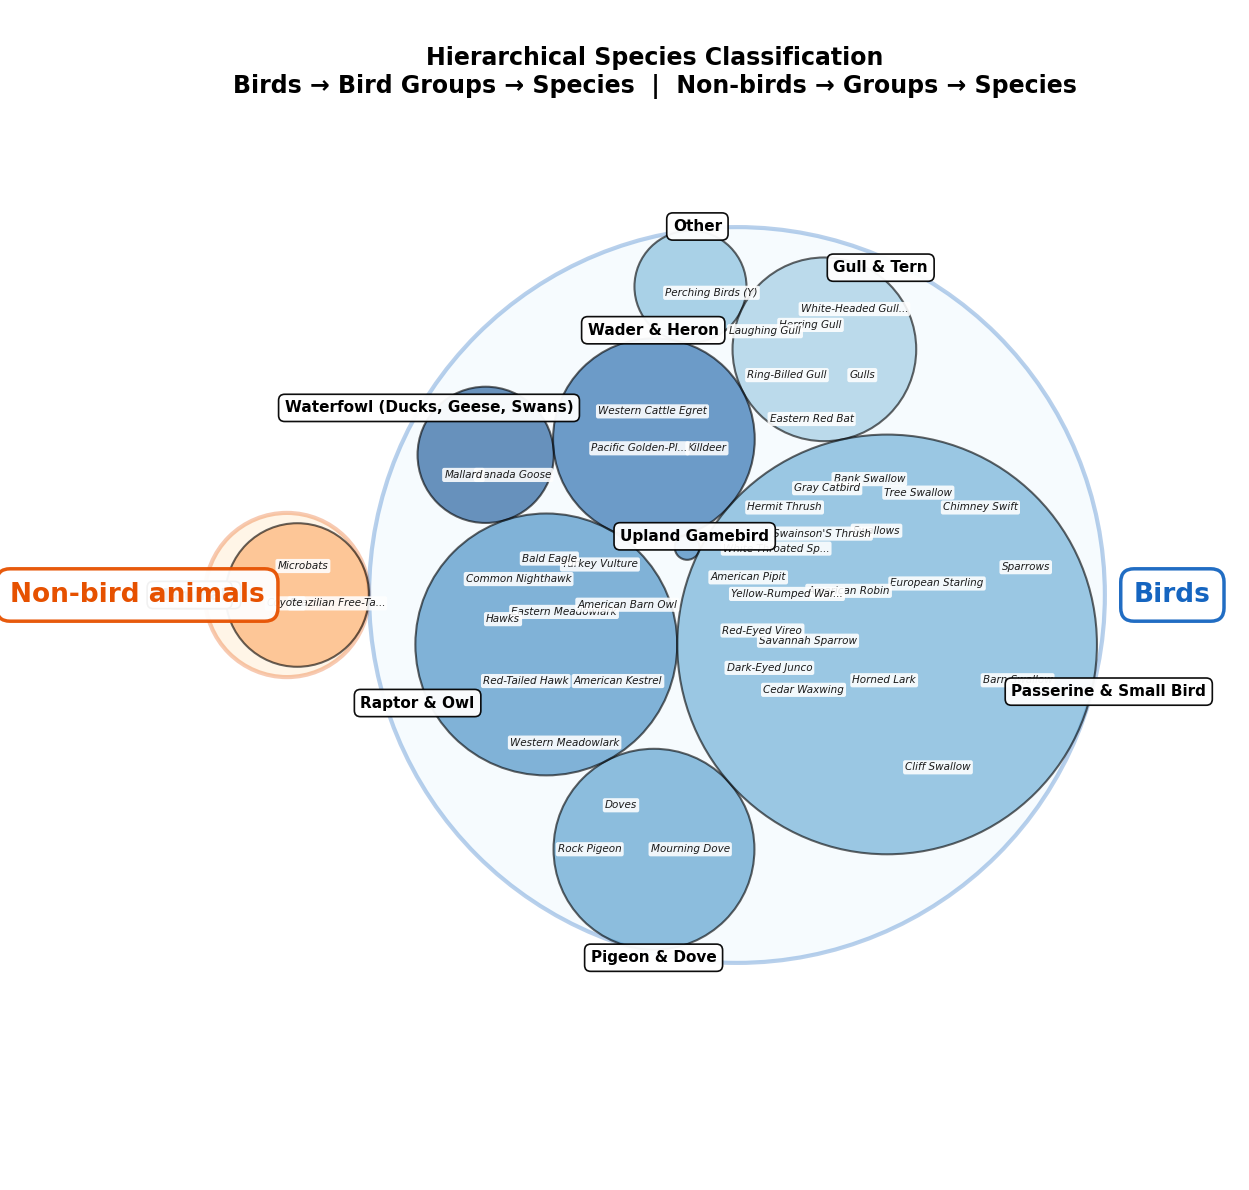


✓ PLOTAGEM CONCLUÍDA COM SUCESSO!
  📊 Estatísticas:
     • 2 categorias principais (Birds/Non-birds)
     • 10 grupos de espécies
     • 372 espécies TOTAIS disponíveis
     • 47 espécies EXIBIDAS (sem overlap)
     • 325 espécies OCULTAS (overlap ou muito pequenas)

  ℹ️  Tamanho dos círculos = frequência nos dados
  ℹ️  Taxa de exibição: 12.6%



In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import circlify
import matplotlib.patheffects as pe
from matplotlib.patches import FancyBboxPatch

# -----------------------------
# SPECIES MAPPING (do seu código)
# -----------------------------
species_mapping = {
    "Waterfowl (Ducks, Geese, Swans)": [
        "duck", "teal", "wigeon", "scoter", "eider", "goldeneye", "goose", "swan", "brant",
        "cackling goose", "pintail", "merganser", "mallard", "redhead", "northern shoveler",
        "mottled duck", "gadwall", "muscovy duck", "american wigeon", "american black duck",
        "canvasback", "greater white-fronted goose", "lesser scaup", "ring-necked duck",
        "common goldeneye", "long-tailed duck", "bufflehead", "surf scoter", "black-bellied whistling-duck",
        "barrow's goldeneye", "greater scaup", "cinnamon teal", "hawaiian duck", "diving duck (aythya)",
        "snow goose"
    ],
    "Raptor & Owl": [
        "hawk", "kestrel", "falcon", "vulture", "eagle", "osprey", "harrier", "merlin", "caracara",
        "buzzard", "owl", "screech-owl", "kite", "peregrine falcon", "red-tailed hawk",
        "american kestrel", "bald eagle", "turkey vulture", "great horned owl", "swainson's hawk",
        "red-shouldered hawk", "northern harrier", "cooper's hawk", "prairie falcon", "crested caracara",
        "northern hawk owl", "sharp-shinned hawk", "ferruginous hawk", "golden eagle", "mississippi kite",
        "harris's hawk", "eurasian buzzard", "great gray owl", "gyrfalcon"
    ],
    "Wader & Heron": [
        "sandpiper", "plover", "snipe", "dowitcher", "turnstone", "godwit", "stilt", "avocet",
        "phalarope", "curlew", "ibis", "spoonbill", "willet", "shorebird", "heron", "egret",
        "bittern", "cormorant", "pelican", "loon", "grebe", "oystercatcher", "stork", "gallinule",
        "crane", "killdeer", "pacific golden-plover", "western cattle egret", "american coot",
        "great blue heron", "sandhill crane", "black-bellied plover", "upland sandpiper",
        "western sandpiper", "american bittern", "california gull", "western gull",
        "american golden-plover", "black-crowned night heron", "least sandpiper",
        "double-crested cormorant", "semipalmated plover", "lesser yellowlegs", "snowy egret",
        "wilson's snipe", "dunlin", "semipalmated sandpiper", "great egret", "green heron",
        "wood stork", "sanderling", "long-billed dowitcher", "pectoral sandpiper", "pied-billed grebe",
        "common loon", "anhinga", "yellow-crowned night heron", "whooping crane", "whimbrel",
        "red knot", "short-billed dowitcher", "red-throated loon", "black-necked stilt",
        "greater yellowlegs", "american avocet", "spotted sandpiper", "least bittern", "sora",
        "wilson's plover", "piping plover", "red-necked phalarope", "wilson's phalarope",
        "long-billed curlew", "ruddy turnstone", "red-necked grebe",
        "brandt's cormorant", "white-faced ibis", "marbled godwit", "glossy ibis", "roseate spoonbill",
        "black skimmer", "tricolored heron", "forster's tern", "connecticut warbler", "eurasian collared dove"
    ],
    "Gull & Tern": [
        "gull", "tern", "noddy", "kittiwake", "ring-billed gull", "herring gull", "laughing gull",
        "short-billed gull", "heermann's gull", "bonaparte's gull", "caspian tern", "franklin's gull",
        "great black-backed gull", "glaucous-winged gull", "lesser black-backed gull", "common tern",
        "least tern", "sooty tern", "royal tern", "elegant tern"
    ],
    "Passerine & Small Bird": [
        "sparrow", "swallow", "robin", "starling", "lark", "kingfisher", "wren", "thrush", "pipit",
        "grosbeak", "bunting", "crow", "raven", "mockingbird", "grackle", "jay", "magpie",
        "oriole", "woodpecker", "flycatcher", "vireo", "tanager", "chat", "cardinal", "finch",
        "nuthatch", "hummingbird", "parakeet", "parrot", "canary", "drongo", "myna", "waxwing",
        "chickadee", "warbler", "swift", "western meadowlark", "american robin", "blackbird",
        "savannah sparrow", "american crow", "horned lark", "purple martin", "northern mockingbird",
        "snow bunting", "eastern meadowlark", "brown-headed cowbird", "bank swallow", "common yellowthroat",
        "common raven", "black-and-white warbler", "common grackle", "great-tailed grackle",
        "hairy woodpecker", "scissor-tailed flycatcher", "red-vented bulbul", "common myna",
        "fox sparrow", "american pipit", "acadian flycatcher", "song sparrow", "western bluebird",
        "american goldfinch", "yellow-billed magpie", "dark-eyed junco", "cedar waxwing",
        "western kingbird", "blue jay", "brewer's blackbird", "black-billed magpie", "eastern kingbird",
        "lark bunting", "house sparrow", "swainson's thrush", "varied thrush", "hermit thrush",
        "blackpoll warbler", "yellow warbler", "yellow-rumped warbler", "eastern phoebe",
        "lapland longspur", "pine warbler", "northern rough-winged swallow", "orchard oriole",
        "mountain chickadee", "chestnut-collared longspur", "ovenbird", "northern flicker",
        "brown thrasher", "ruby-throated hummingbird", "chipping sparrow", "golden-crowned kinglet",
        "grasshopper sparrow", "bohemian waxwing", "wilson's warbler", "loggerhead shrike",
        "american tree sparrow", "lincoln's sparrow", "field sparrow", "gray catbird",
        "blue-gray gnatcatcher", "vesper sparrow", "eurasian skylark", "white-throated swift",
        "anna's hummingbird", "pine siskin", "western tanager", "bell's sparrow", "mountain bluebird",
        "boat-tailed grackle", "northern parula", "bobolink", "california towhee", "cactus wren",
        "tropical mockingbird", "cave swallow", "ruby-crowned kinglet", "broad-winged hawk",
        "carolina chickadee", "swamp sparrow", "northern house wren", "white-crowned sparrow",
        "indian silverbill", "lesser goldfinch", "western flycatcher", "lark sparrow", "veery",
        "cassin's vireo", "yellow-headed blackbird", "yellow-billed cuckoo", "gray-cheeked thrush",
        "purple finch", "nelson's sparrow", "japanese white-eye", "tennessee warbler",
        "blackburnian warbler", "orange-crowned warbler", "baltimore oriole", "black drongo",
        "bushtit", "black-throated blue warbler", "red-eyed vireo", "canada warbler", "pine grosbeak",
        "black-throated green warbler", "yellow-breasted chat", "warbling vireo", "magnolia warbler",
        "northern waterthrush", "brewer's sparrow", "black-headed grosbeak", "eastern whip-poor-will",
        "dickcissel", "willow flycatcher", "rose-breasted grosbeak", "yellow-throated warbler",
        "american redstart", "cape may warbler", "marsh wren", "sprague's pipit", "indigo bunting",
        "palm warbler", "harris's sparrow", "prairie warbler", "eastern bluebird", "green-tailed towhee",
        "mourning warbler", "black-billed cuckoo", "kentucky warbler", "smith's longspur",
        "carolina wren", "eastern wood-pewee", "yellow-bellied flycatcher", "summer tanager",
        "scarlet tanager", "chestnut-sided warbler", "clay-colored sparrow", "wood thrush",
        "hooded warbler", "leconte's sparrow", "least flycatcher", "hammond's flycatcher",
        "eastern towhee", "winter wren", "bay-breasted warbler", "redpoll", "meadow pipit",
        "say's phoebe", "red crossbill", "worm-eating warbler", "nanday parakeet",
        "yellow-throated vireo", "white-eyed vireo", "hooded oriole", "black-throated gray warbler",
        "bullock's oriole", "ash-throated flycatcher", "downy woodpecker", "black-chinned hummingbird",
        "sedge wren", "painted bunting", "hermit warbler", "saffron finch", "common raven"
    ],
    "Pigeon & Dove": ["pigeon", "dove", "rock pigeon", "mourning dove", "zebra dove", "spotted dove", "white-winged dove", "common ground dove", "band-tailed pigeon", "eurasian collared dove", "zenaida dove", "white-crowned pigeon"],
    "Upland Gamebird": ["pheasant", "quail", "grouse", "francolin", "partridge", "chukar", "wild turkey", "northern bobwhite", "gray partridge", "greater sage-grouse", "sharp-tailed grouse", "scaled quail", "gambel's quail", "helmeted guineafowl"],
    "Mammal": [
        "deer", "coyote", "rabbit", "bat", "opossum", "skunk", "racoon", "porcupine", "squirrel",
        "mink", "badger", "nutria", "canid", "bear", "pig", "moose", "elk", "caribou", "fox",
        "coypu", "cattle", "otter", "woodchuck", "pronghorn", "armadillo", "gopher", "dog", "cat",
        "peccary", "mongoose", "marmot", "prairie dog", "muskrat", "hare", "white-tailed deer",
        "river otter", "wapiti (elk)", "eastern cottontail", "mule deer", "black-tailed jackrabbit",
        "striped skunk", "nine-banded armadillo", "white-tailed jackrabbit", "gunnison's prairie dog",
        "north american porcupine", "yellow-bellied marmot", "white-tailed prairie dog",
        "black-tailed prairie dog", "eastern red bat", "collared peccary", "small indian mongoose",
        "kit fox", "common gray fox", "big brown bat", "silver-haired bat", "hoary bat",
        "florida bonneted bat", "yuma myotis", "jamaican fruit bat", "evening bat", "american badger",
        "american mink"
    ],
    "Reptile": ["turtle", "snake", "alligator", "lizard", "iguana", "terrapin", "rattlesnake", "common snapping turtle", "pond slider", "diamondback terrapin", "gopher tortoise", "eastern diamondback rattlesnake", "green iguana"],
    "Unknown": ["unknown bird - medium", "unknown bird - small", "unknown bird - large"]
}

def consolidate_species(species):
    """Agrupa espécies em categorias"""
    species_lower = str(species).lower()
    for group, keywords in species_mapping.items():
        if any(keyword in species_lower for keyword in keywords):
            return group
    return "Other"

def is_bird_species(species_group):
    """Identifica se o grupo é ave ou não"""
    non_bird_groups = ['Mammal', 'Reptile']
    return False if species_group in non_bird_groups else True

# -----------------------------
# PROCESSAMENTO DOS DADOS
# -----------------------------
data = data_strike.copy()

# Classificação
data["SPECIES_GROUP"] = data["SPECIES"].apply(consolidate_species)
data["IS_BIRD"] = data["SPECIES_GROUP"].apply(is_bird_species)

# Remove "Unknown"
mask_unknown_text = data["SPECIES"].astype(str).str.lower().str.contains("unknown|unknow")
mask_unknown_group = data["SPECIES_GROUP"].str.lower().eq("unknown")
data = data.loc[~mask_unknown_text & ~mask_unknown_group].copy()

# Separa aves e não-aves
birds = data.loc[data["IS_BIRD"] == True].copy()
nonbirds = data.loc[data["IS_BIRD"] == False].copy()

# -----------------------------
# FREQUÊNCIAS - TODAS AS ESPÉCIES
# -----------------------------
# Aumentado drasticamente para capturar todas as espécies
TOP_N_PER_BIRD_GROUP = 50  
TOP_N_PER_NONBIRD_GROUP = 30

freq_birds = (
    birds.groupby(["SPECIES_GROUP", "SPECIES"])
         .size()
         .reset_index(name="n")
         .sort_values(["SPECIES_GROUP", "n"], ascending=[True, False])
         .groupby("SPECIES_GROUP")
         .head(TOP_N_PER_BIRD_GROUP)
)

freq_non = (
    nonbirds.groupby(["SPECIES_GROUP", "SPECIES"])
            .size()
            .reset_index(name="n")
            .sort_values(["SPECIES_GROUP", "n"], ascending=[True, False])
            .groupby("SPECIES_GROUP")
            .head(TOP_N_PER_NONBIRD_GROUP)
)

has_nonbirds = len(freq_non) > 0

# -----------------------------
# HIERARQUIA SEM 'parent' (corrige o warning)
# -----------------------------
def build_three_level_hierarchy(df_freq, top_name):
    """Constrói hierarquia: Top → Grupos → Espécies (SEM parent no dict)"""
    nodes_lvl2 = []
    for g, gdf in df_freq.groupby("SPECIES_GROUP"):
        children = [
            {"id": sp, "datum": int(n)}  # SEM 'parent'
            for sp, n in zip(gdf["SPECIES"], gdf["n"])
        ]
        nodes_lvl2.append({
            "id": g,
            "datum": int(gdf["n"].sum()),
            "children": children
        })

    return {
        "id": top_name,
        "datum": int(df_freq["n"].sum()),
        "children": nodes_lvl2
    }

birds_tree = build_three_level_hierarchy(freq_birds, "Birds")

hierarchy = [birds_tree]
if has_nonbirds:
    non_tree = build_three_level_hierarchy(freq_non, "Non-bird animals")
    hierarchy.append(non_tree)

# -----------------------------
# CIRCLE PACKING
# -----------------------------
circles = circlify.circlify(
    hierarchy,
    show_enclosure=True,
    target_enclosure=circlify.Circle(x=0, y=0, r=1.0)
)

def ex_dict(c):
    return c.ex if isinstance(c.ex, dict) else {}

lvl1 = [c for c in circles if c.level == 1 and "id" in ex_dict(c)]
lvl2 = [c for c in circles if c.level == 2 and "id" in ex_dict(c)]
lvl3 = [c for c in circles if c.level == 3 and "id" in ex_dict(c)]

# Criar mapeamento manual de parent (grupo → top_level)
group_to_parent = {}
for top in hierarchy:
    top_name = top["id"]
    for group_node in top.get("children", []):
        group_to_parent[group_node["id"]] = top_name

# Criar mapeamento de espécie → grupo
species_to_group = {}
for top in hierarchy:
    for group_node in top.get("children", []):
        group_name = group_node["id"]
        for species_node in group_node.get("children", []):
            species_to_group[species_node["id"]] = group_name

# -----------------------------
# CORES APRIMORADAS
# -----------------------------
top_colors = {
    "Birds": "#E3F2FD",
    "Non-bird animals": "#FFE0B2"
}
top_edges = {
    "Birds": "#1565C0",
    "Non-bird animals": "#E65100"
}

bird_group_palette = plt.cm.Blues
non_group_palette = plt.cm.Oranges

bird_groups = sorted(freq_birds["SPECIES_GROUP"].unique())
non_groups = sorted(freq_non["SPECIES_GROUP"].unique()) if has_nonbirds else []

bird_group_color = {
    g: bird_group_palette(0.4 + 0.5*i/max(1, len(bird_groups)-1))
    for i, g in enumerate(bird_groups)
}
non_group_color = {
    g: non_group_palette(0.4 + 0.5*i/max(1, len(non_groups)-1))
    for i, g in enumerate(non_groups)
}

def color_for_group(parent_top, group_name):
    if parent_top == "Birds":
        return bird_group_color.get(group_name, "#90CAF9")
    else:
        return non_group_color.get(group_name, "#FFAB91")

# -----------------------------
# FUNÇÃO PARA VERIFICAR OVERLAP
# -----------------------------
def text_overlaps(x1, y1, w1, h1, x2, y2, w2, h2, buffer=0.015):
    """Verifica se dois retângulos de texto se sobrepõem"""
    return not (x1 + w1/2 + buffer < x2 - w2/2 or 
                x1 - w1/2 > x2 + w2/2 + buffer or
                y1 + h1/2 + buffer < y2 - h2/2 or
                y1 - h1/2 > y2 + h2/2 + buffer)

# -----------------------------
# PLOT
# -----------------------------
fig, ax = plt.subplots(figsize=(20, 12), facecolor='white')
ax.axis("off")
ax.set_aspect("equal")
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)

title_text = "Hierarchical Species Classification\nBirds → Bird Groups → Species  |  Non-birds → Groups → Species"
ax.text(0, 1.22, title_text, ha="center", va="top", fontsize=17, weight="bold")

# --- NÍVEL 1: Birds / Non-birds ---
for c in lvl1:
    top_name = ex_dict(c)["id"]
    x, y, r = c.x, c.y, c.r
    fc = top_colors.get(top_name, "#E0E0E0")
    ec = top_edges.get(top_name, "#424242")

    circle = plt.Circle((x, y), r, facecolor=fc, edgecolor=ec,
                        linewidth=3, alpha=0.3, zorder=1)
    ax.add_patch(circle)
    
    # Label do nível 1
    angle = np.arctan2(y, x) if np.hypot(x, y) > 0.01 else 0
    label_x = x + np.cos(angle) * (r + 0.15)
    label_y = y + np.sin(angle) * (r + 0.15)
    
    ax.text(label_x, label_y, top_name, ha="center", va="center",
            fontsize=19, weight="bold", color=ec,
            bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor=ec, linewidth=2.5, alpha=0.95),
            zorder=15)

# --- NÍVEL 2: Grupos ---
group_positions = {}

for c in lvl2:
    group = ex_dict(c)["id"]
    parent_top = group_to_parent.get(group, "Birds")
    x, y, r = c.x, c.y, c.r
    col = color_for_group(parent_top, group)

    circle = plt.Circle((x, y), r, facecolor=col, edgecolor="black",
                        linewidth=1.5, alpha=0.6, zorder=2)
    ax.add_patch(circle)
    
    # Posicionar label FORA
    angle = np.arctan2(y, x) if np.hypot(x, y) > 0.01 else np.random.uniform(0, 2*np.pi)
    
    best_pos = None
    for offset_mult in [1.08, 1.15, 1.25, 1.35, 1.45]:
        label_x = x + np.cos(angle) * r * offset_mult
        label_y = y + np.sin(angle) * r * offset_mult
        
        has_overlap = False
        for other_pos in group_positions.values():
            if text_overlaps(label_x, label_y, 0.15, 0.08, other_pos[0], other_pos[1], 0.15, 0.08):
                has_overlap = True
                break
        
        if not has_overlap:
            best_pos = (label_x, label_y)
            break
    
    if best_pos is None:
        best_pos = (x + np.cos(angle) * r * 1.5, y + np.sin(angle) * r * 1.5)
    
    group_positions[group] = best_pos
    
    ax.text(best_pos[0], best_pos[1], group, ha="center", va="center",
            fontsize=11, weight="bold",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="black", 
                     linewidth=1.2, alpha=0.95),
            zorder=12)

# --- NÍVEL 3: TODAS AS ESPÉCIES POSSÍVEIS ---
R_MIN = 0.038  # Raio mínimo reduzido para pegar mais espécies

# Agrupa espécies por grupo
by_group = {}
for c in lvl3:
    sp = ex_dict(c)["id"]
    g = species_to_group.get(sp)
    by_group.setdefault(g, []).append(c)

species_positions = []  # (x, y, width, height)
species_plotted = 0
species_skipped = 0

for g, circles_sp in by_group.items():
    # Ordena por tamanho (mantém TODAS)
    circles_sp = sorted(circles_sp, key=lambda cc: cc.r, reverse=True)
    
    for c in circles_sp:
        sp = ex_dict(c)["id"]
        x, y, r = c.x, c.y, c.r
        
        # Pula apenas os muito pequenos
        if r < R_MIN:
            species_skipped += 1
            continue
        
        # Estima largura e altura do texto
        sp_display = sp.title()
        if len(sp_display) > 20:
            sp_display = sp_display[:17] + "..."
        
        # Largura/altura aproximadas baseadas no tamanho da fonte
        char_width = 0.006
        text_width = len(sp_display) * char_width
        text_height = 0.025
        
        # Verifica overlap com TODOS os textos já plotados
        has_overlap = False
        for (px, py, pw, ph) in species_positions:
            if text_overlaps(x, y, text_width, text_height, px, py, pw, ph, buffer=0.008):
                has_overlap = True
                break
        
        if has_overlap:
            species_skipped += 1
            continue
        
        # Plota a espécie
        bbox_props = dict(boxstyle="round,pad=0.2", facecolor="white", 
                         edgecolor="none", alpha=0.88)
        
        ax.text(x, y, sp_display, ha="center", va="center",
                fontsize=7.5, style="italic", color="#1A1A1A",
                bbox=bbox_props,
                zorder=10)
        
        species_positions.append((x, y, text_width, text_height))
        species_plotted += 1

plt.tight_layout()
plt.show()

# Estatísticas
print(f"\n{'='*70}")
print(f"✓ PLOTAGEM CONCLUÍDA COM SUCESSO!")
print(f"{'='*70}")
print(f"  📊 Estatísticas:")
print(f"     • {len(lvl1)} categorias principais (Birds/Non-birds)")
print(f"     • {len(lvl2)} grupos de espécies")
print(f"     • {len(lvl3)} espécies TOTAIS disponíveis")
print(f"     • {species_plotted} espécies EXIBIDAS (sem overlap)")
print(f"     • {species_skipped} espécies OCULTAS (overlap ou muito pequenas)")
print(f"\n  ℹ️  Tamanho dos círculos = frequência nos dados")
print(f"  ℹ️  Taxa de exibição: {species_plotted/len(lvl3)*100:.1f}%")
print(f"{'='*70}\n")

unexpected key 'parent' in input is ignored
unexpected key 'parent' in input is ignored
unexpected key 'parent' in input is ignored
unexpected key 'parent' in input is ignored
unexpected key 'parent' in input is ignored
unexpected key 'parent' in input is ignored
unexpected key 'parent' in input is ignored
unexpected key 'parent' in input is ignored
unexpected key 'parent' in input is ignored
unexpected key 'parent' in input is ignored
unexpected key 'parent' in input is ignored
unexpected key 'parent' in input is ignored
unexpected key 'parent' in input is ignored
unexpected key 'parent' in input is ignored
unexpected key 'parent' in input is ignored
unexpected key 'parent' in input is ignored
unexpected key 'parent' in input is ignored
unexpected key 'parent' in input is ignored
unexpected key 'parent' in input is ignored
unexpected key 'parent' in input is ignored
unexpected key 'parent' in input is ignored
unexpected key 'parent' in input is ignored
unexpected key 'parent' in input

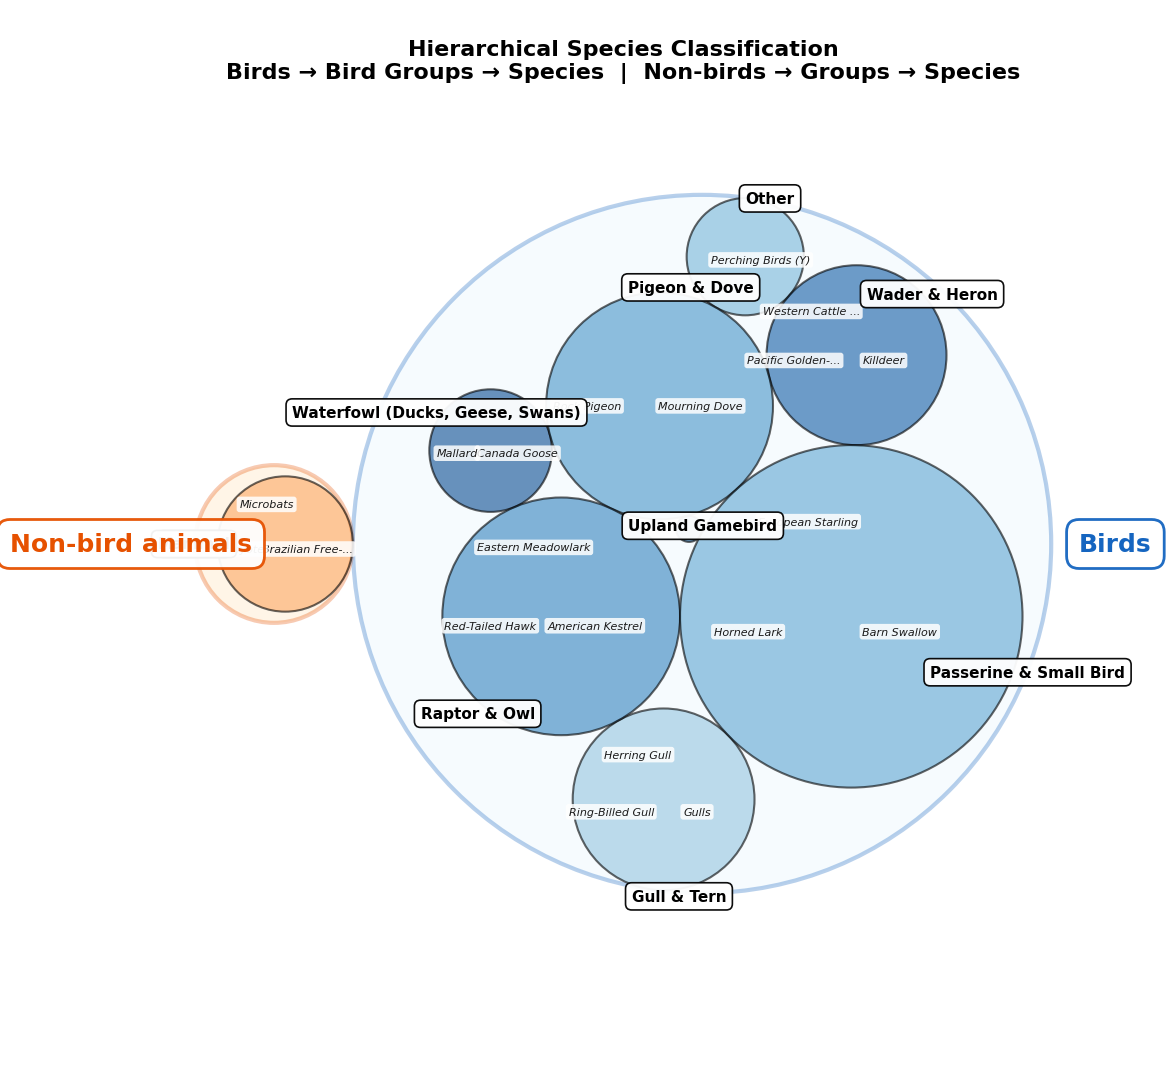


✓ PLOTAGEM CONCLUÍDA COM SUCESSO!
  📊 Estatísticas:
     • 2 categorias principais (Birds/Non-birds)
     • 10 grupos de espécies
     • 50 espécies totais no dataset
     • 20 espécies exibidas (sem overlap)

  ℹ️  Tamanho dos círculos = frequência nos dados
  ℹ️  Apenas top 3 espécies por grupo são mostradas



In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import circlify
import matplotlib.patheffects as pe
from matplotlib.patches import FancyBboxPatch

# -----------------------------
# SPECIES MAPPING (do seu código)
# -----------------------------
species_mapping = {
    "Waterfowl (Ducks, Geese, Swans)": [
        "duck", "teal", "wigeon", "scoter", "eider", "goldeneye", "goose", "swan", "brant",
        "cackling goose", "pintail", "merganser", "mallard", "redhead", "northern shoveler",
        "mottled duck", "gadwall", "muscovy duck", "american wigeon", "american black duck",
        "canvasback", "greater white-fronted goose", "lesser scaup", "ring-necked duck",
        "common goldeneye", "long-tailed duck", "bufflehead", "surf scoter", "black-bellied whistling-duck",
        "barrow's goldeneye", "greater scaup", "cinnamon teal", "hawaiian duck", "diving duck (aythya)",
        "snow goose"
    ],
    "Raptor & Owl": [
        "hawk", "kestrel", "falcon", "vulture", "eagle", "osprey", "harrier", "merlin", "caracara",
        "buzzard", "owl", "screech-owl", "kite", "peregrine falcon", "red-tailed hawk",
        "american kestrel", "bald eagle", "turkey vulture", "great horned owl", "swainson's hawk",
        "red-shouldered hawk", "northern harrier", "cooper's hawk", "prairie falcon", "crested caracara",
        "northern hawk owl", "sharp-shinned hawk", "ferruginous hawk", "golden eagle", "mississippi kite",
        "harris's hawk", "eurasian buzzard", "great gray owl", "gyrfalcon"
    ],
    "Wader & Heron": [
        "sandpiper", "plover", "snipe", "dowitcher", "turnstone", "godwit", "stilt", "avocet",
        "phalarope", "curlew", "ibis", "spoonbill", "willet", "shorebird", "heron", "egret",
        "bittern", "cormorant", "pelican", "loon", "grebe", "oystercatcher", "stork", "gallinule",
        "crane", "killdeer", "pacific golden-plover", "western cattle egret", "american coot",
        "great blue heron", "sandhill crane", "black-bellied plover", "upland sandpiper",
        "western sandpiper", "american bittern", "california gull", "western gull",
        "american golden-plover", "black-crowned night heron", "least sandpiper",
        "double-crested cormorant", "semipalmated plover", "lesser yellowlegs", "snowy egret",
        "wilson's snipe", "dunlin", "semipalmated sandpiper", "great egret", "green heron",
        "wood stork", "sanderling", "long-billed dowitcher", "pectoral sandpiper", "pied-billed grebe",
        "common loon", "anhinga", "yellow-crowned night heron", "whooping crane", "whimbrel",
        "red knot", "short-billed dowitcher", "red-throated loon", "black-necked stilt",
        "greater yellowlegs", "american avocet", "spotted sandpiper", "least bittern", "sora",
        "wilson's plover", "piping plover", "red-necked phalarope", "wilson's phalarope",
        "long-billed curlew", "ruddy turnstone", "red-necked grebe",
        "brandt's cormorant", "white-faced ibis", "marbled godwit", "glossy ibis", "roseate spoonbill",
        "black skimmer", "tricolored heron", "forster's tern", "connecticut warbler", "eurasian collared dove"
    ],
    "Gull & Tern": [
        "gull", "tern", "noddy", "kittiwake", "ring-billed gull", "herring gull", "laughing gull",
        "short-billed gull", "heermann's gull", "bonaparte's gull", "caspian tern", "franklin's gull",
        "great black-backed gull", "glaucous-winged gull", "lesser black-backed gull", "common tern",
        "least tern", "sooty tern", "royal tern", "elegant tern"
    ],
    "Passerine & Small Bird": [
        "sparrow", "swallow", "robin", "starling", "lark", "kingfisher", "wren", "thrush", "pipit",
        "grosbeak", "bunting", "crow", "raven", "mockingbird", "grackle", "jay", "magpie",
        "oriole", "woodpecker", "flycatcher", "vireo", "tanager", "chat", "cardinal", "finch",
        "nuthatch", "hummingbird", "parakeet", "parrot", "canary", "drongo", "myna", "waxwing",
        "chickadee", "warbler", "swift", "western meadowlark", "american robin", "blackbird",
        "savannah sparrow", "american crow", "horned lark", "purple martin", "northern mockingbird",
        "snow bunting", "eastern meadowlark", "brown-headed cowbird", "bank swallow", "common yellowthroat",
        "common raven", "black-and-white warbler", "common grackle", "great-tailed grackle",
        "hairy woodpecker", "scissor-tailed flycatcher", "red-vented bulbul", "common myna",
        "fox sparrow", "american pipit", "acadian flycatcher", "song sparrow", "western bluebird",
        "american goldfinch", "yellow-billed magpie", "dark-eyed junco", "cedar waxwing",
        "western kingbird", "blue jay", "brewer's blackbird", "black-billed magpie", "eastern kingbird",
        "lark bunting", "house sparrow", "swainson's thrush", "varied thrush", "hermit thrush",
        "blackpoll warbler", "yellow warbler", "yellow-rumped warbler", "eastern phoebe",
        "lapland longspur", "pine warbler", "northern rough-winged swallow", "orchard oriole",
        "mountain chickadee", "chestnut-collared longspur", "ovenbird", "northern flicker",
        "brown thrasher", "ruby-throated hummingbird", "chipping sparrow", "golden-crowned kinglet",
        "grasshopper sparrow", "bohemian waxwing", "wilson's warbler", "loggerhead shrike",
        "american tree sparrow", "lincoln's sparrow", "field sparrow", "gray catbird",
        "blue-gray gnatcatcher", "vesper sparrow", "eurasian skylark", "white-throated swift",
        "anna's hummingbird", "pine siskin", "western tanager", "bell's sparrow", "mountain bluebird",
        "boat-tailed grackle", "northern parula", "bobolink", "california towhee", "cactus wren",
        "tropical mockingbird", "cave swallow", "ruby-crowned kinglet", "broad-winged hawk",
        "carolina chickadee", "swamp sparrow", "northern house wren", "white-crowned sparrow",
        "indian silverbill", "lesser goldfinch", "western flycatcher", "lark sparrow", "veery",
        "cassin's vireo", "yellow-headed blackbird", "yellow-billed cuckoo", "gray-cheeked thrush",
        "purple finch", "nelson's sparrow", "japanese white-eye", "tennessee warbler",
        "blackburnian warbler", "orange-crowned warbler", "baltimore oriole", "black drongo",
        "bushtit", "black-throated blue warbler", "red-eyed vireo", "canada warbler", "pine grosbeak",
        "black-throated green warbler", "yellow-breasted chat", "warbling vireo", "magnolia warbler",
        "northern waterthrush", "brewer's sparrow", "black-headed grosbeak", "eastern whip-poor-will",
        "dickcissel", "willow flycatcher", "rose-breasted grosbeak", "yellow-throated warbler",
        "american redstart", "cape may warbler", "marsh wren", "sprague's pipit", "indigo bunting",
        "palm warbler", "harris's sparrow", "prairie warbler", "eastern bluebird", "green-tailed towhee",
        "mourning warbler", "black-billed cuckoo", "kentucky warbler", "smith's longspur",
        "carolina wren", "eastern wood-pewee", "yellow-bellied flycatcher", "summer tanager",
        "scarlet tanager", "chestnut-sided warbler", "clay-colored sparrow", "wood thrush",
        "hooded warbler", "leconte's sparrow", "least flycatcher", "hammond's flycatcher",
        "eastern towhee", "winter wren", "bay-breasted warbler", "redpoll", "meadow pipit",
        "say's phoebe", "red crossbill", "worm-eating warbler", "nanday parakeet",
        "yellow-throated vireo", "white-eyed vireo", "hooded oriole", "black-throated gray warbler",
        "bullock's oriole", "ash-throated flycatcher", "downy woodpecker", "black-chinned hummingbird",
        "sedge wren", "painted bunting", "hermit warbler", "saffron finch", "common raven"
    ],
    "Pigeon & Dove": ["pigeon", "dove", "rock pigeon", "mourning dove", "zebra dove", "spotted dove", "white-winged dove", "common ground dove", "band-tailed pigeon", "eurasian collared dove", "zenaida dove", "white-crowned pigeon"],
    "Upland Gamebird": ["pheasant", "quail", "grouse", "francolin", "partridge", "chukar", "wild turkey", "northern bobwhite", "gray partridge", "greater sage-grouse", "sharp-tailed grouse", "scaled quail", "gambel's quail", "helmeted guineafowl"],
    "Mammal": [
        "deer", "coyote", "rabbit", "bat", "opossum", "skunk", "racoon", "porcupine", "squirrel",
        "mink", "badger", "nutria", "canid", "bear", "pig", "moose", "elk", "caribou", "fox",
        "coypu", "cattle", "otter", "woodchuck", "pronghorn", "armadillo", "gopher", "dog", "cat",
        "peccary", "mongoose", "marmot", "prairie dog", "muskrat", "hare", "white-tailed deer",
        "river otter", "wapiti (elk)", "eastern cottontail", "mule deer", "black-tailed jackrabbit",
        "striped skunk", "nine-banded armadillo", "white-tailed jackrabbit", "gunnison's prairie dog",
        "north american porcupine", "yellow-bellied marmot", "white-tailed prairie dog",
        "black-tailed prairie dog", "eastern red bat", "collared peccary", "small indian mongoose",
        "kit fox", "common gray fox", "big brown bat", "silver-haired bat", "hoary bat",
        "florida bonneted bat", "yuma myotis", "jamaican fruit bat", "evening bat", "american badger",
        "american mink"
    ],
    "Reptile": ["turtle", "snake", "alligator", "lizard", "iguana", "terrapin", "rattlesnake", "common snapping turtle", "pond slider", "diamondback terrapin", "gopher tortoise", "eastern diamondback rattlesnake", "green iguana"],
    "Unknown": ["unknown bird - medium", "unknown bird - small", "unknown bird - large"]
}

def consolidate_species(species):
    """Agrupa espécies em categorias"""
    species_lower = str(species).lower()
    for group, keywords in species_mapping.items():
        if any(keyword in species_lower for keyword in keywords):
            return group
    return "Other"

def is_bird_species(species_group):
    """Identifica se o grupo é ave ou não"""
    non_bird_groups = ['Mammal', 'Reptile']
    return False if species_group in non_bird_groups else True

# -----------------------------
# PROCESSAMENTO DOS DADOS
# -----------------------------
data = data_strike.copy()

# Classificação
data["SPECIES_GROUP"] = data["SPECIES"].apply(consolidate_species)
data["IS_BIRD"] = data["SPECIES_GROUP"].apply(is_bird_species)

# Remove "Unknown"
mask_unknown_text = data["SPECIES"].astype(str).str.lower().str.contains("unknown|unknow")
mask_unknown_group = data["SPECIES_GROUP"].str.lower().eq("unknown")
data = data.loc[~mask_unknown_text & ~mask_unknown_group].copy()

# Separa aves e não-aves
birds = data.loc[data["IS_BIRD"] == True].copy()
nonbirds = data.loc[data["IS_BIRD"] == False].copy()

# -----------------------------
# FREQUÊNCIAS
# -----------------------------
TOP_N_PER_BIRD_GROUP = 5  # Reduzido drasticamente
TOP_N_PER_NONBIRD_GROUP = 5

freq_birds = (
    birds.groupby(["SPECIES_GROUP", "SPECIES"])
         .size()
         .reset_index(name="n")
         .sort_values(["SPECIES_GROUP", "n"], ascending=[True, False])
         .groupby("SPECIES_GROUP")
         .head(TOP_N_PER_BIRD_GROUP)
)

freq_non = (
    nonbirds.groupby(["SPECIES_GROUP", "SPECIES"])
            .size()
            .reset_index(name="n")
            .sort_values(["SPECIES_GROUP", "n"], ascending=[True, False])
            .groupby("SPECIES_GROUP")
            .head(TOP_N_PER_NONBIRD_GROUP)
)

has_nonbirds = len(freq_non) > 0

# -----------------------------
# HIERARQUIA DE 3 NÍVEIS
# -----------------------------
def build_three_level_hierarchy(df_freq, top_name):
    """Constrói hierarquia: Top → Grupos → Espécies"""
    nodes_lvl2 = []
    for g, gdf in df_freq.groupby("SPECIES_GROUP"):
        children = [
            {"id": sp, "datum": int(n), "parent": g}
            for sp, n in zip(gdf["SPECIES"], gdf["n"])
        ]
        nodes_lvl2.append({
            "id": g,
            "datum": int(gdf["n"].sum()),
            "children": children,
            "parent": top_name
        })

    return {
        "id": top_name,
        "datum": int(df_freq["n"].sum()),
        "children": nodes_lvl2
    }

birds_tree = build_three_level_hierarchy(freq_birds, "Birds")

hierarchy = [birds_tree]
if has_nonbirds:
    non_tree = build_three_level_hierarchy(freq_non, "Non-bird animals")
    hierarchy.append(non_tree)

# -----------------------------
# CIRCLE PACKING
# -----------------------------
circles = circlify.circlify(
    hierarchy,
    show_enclosure=True,
    target_enclosure=circlify.Circle(x=0, y=0, r=1.0)
)

def ex_dict(c):
    return c.ex if isinstance(c.ex, dict) else {}

lvl1 = [c for c in circles if c.level == 1 and "id" in ex_dict(c)]
lvl2 = [c for c in circles if c.level == 2 and "id" in ex_dict(c)]
lvl3 = [c for c in circles if c.level == 3 and "id" in ex_dict(c)]

# -----------------------------
# CORES APRIMORADAS
# -----------------------------
top_colors = {
    "Birds": "#E3F2FD",
    "Non-bird animals": "#FFE0B2"
}
top_edges = {
    "Birds": "#1565C0",
    "Non-bird animals": "#E65100"
}

bird_group_palette = plt.cm.Blues
non_group_palette = plt.cm.Oranges

bird_groups = sorted(freq_birds["SPECIES_GROUP"].unique())
non_groups = sorted(freq_non["SPECIES_GROUP"].unique()) if has_nonbirds else []

bird_group_color = {
    g: bird_group_palette(0.4 + 0.5*i/max(1, len(bird_groups)-1))
    for i, g in enumerate(bird_groups)
}
non_group_color = {
    g: non_group_palette(0.4 + 0.5*i/max(1, len(non_groups)-1))
    for i, g in enumerate(non_groups)
}

def color_for_group(parent_top, group_name):
    if parent_top == "Birds":
        return bird_group_color.get(group_name, "#90CAF9")
    else:
        return non_group_color.get(group_name, "#FFAB91")

# -----------------------------
# FUNÇÃO PARA VERIFICAR OVERLAP
# -----------------------------
def circles_overlap(x1, y1, r1, x2, y2, r2, buffer=0.02):
    """Verifica se dois círculos se sobrepõem (com buffer)"""
    dist = np.hypot(x2 - x1, y2 - y1)
    return dist < (r1 + r2 + buffer)

# -----------------------------
# PLOT
# -----------------------------
fig, ax = plt.subplots(figsize=(18, 11), facecolor='white')
ax.axis("off")
ax.set_aspect("equal")
ax.set_xlim(-1.25, 1.25)
ax.set_ylim(-1.25, 1.25)

title_text = "Hierarchical Species Classification\nBirds → Bird Groups → Species  |  Non-birds → Groups → Species"
ax.text(0, 1.18, title_text, ha="center", va="top", fontsize=16, weight="bold")

# --- NÍVEL 1: Birds / Non-birds ---
for c in lvl1:
    top_name = ex_dict(c)["id"]
    x, y, r = c.x, c.y, c.r
    fc = top_colors.get(top_name, "#E0E0E0")
    ec = top_edges.get(top_name, "#424242")

    circle = plt.Circle((x, y), r, facecolor=fc, edgecolor=ec,
                        linewidth=3, alpha=0.3, zorder=1)
    ax.add_patch(circle)
    
    # Label do nível 1 (bem fora do círculo)
    angle = np.arctan2(y, x) if np.hypot(x, y) > 0.01 else 0
    label_x = x + np.cos(angle) * (r + 0.15)
    label_y = y + np.sin(angle) * (r + 0.15)
    
    ax.text(label_x, label_y, top_name, ha="center", va="center",
            fontsize=18, weight="bold", color=ec,
            bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor=ec, linewidth=2, alpha=0.95),
            zorder=15)

# --- NÍVEL 2: Grupos (Waterfowl, Raptor, Mammal, etc) ---
group_positions = {}  # Guardar posições para verificar overlaps

for c in lvl2:
    group = ex_dict(c)["id"]
    parent_top = ex_dict(c).get("parent", "Birds")
    x, y, r = c.x, c.y, c.r
    col = color_for_group(parent_top, group)

    circle = plt.Circle((x, y), r, facecolor=col, edgecolor="black",
                        linewidth=1.5, alpha=0.6, zorder=2)
    ax.add_patch(circle)
    
    # Posicionar label FORA do círculo, evitando overlaps
    angle = np.arctan2(y, x) if np.hypot(x, y) > 0.01 else np.random.uniform(0, 2*np.pi)
    
    # Tentar várias posições até encontrar uma sem overlap
    best_pos = None
    for offset_mult in [1.08, 1.15, 1.25, 1.35]:
        label_x = x + np.cos(angle) * r * offset_mult
        label_y = y + np.sin(angle) * r * offset_mult
        
        # Verificar overlap com outros grupos
        has_overlap = False
        for other_pos in group_positions.values():
            if circles_overlap(label_x, label_y, 0.08, other_pos[0], other_pos[1], 0.08):
                has_overlap = True
                break
        
        if not has_overlap:
            best_pos = (label_x, label_y)
            break
    
    if best_pos is None:
        best_pos = (x + np.cos(angle) * r * 1.35, y + np.sin(angle) * r * 1.35)
    
    group_positions[group] = best_pos
    
    ax.text(best_pos[0], best_pos[1], group, ha="center", va="center",
            fontsize=11, weight="bold",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="black", 
                     linewidth=1.2, alpha=0.95),
            zorder=12)

# --- NÍVEL 3: Espécies (DENTRO dos círculos, COM CONTROLE RIGOROSO) ---
R_MIN = 0.055  # Apenas círculos maiores

# Agrupa espécies por grupo
by_group = {}
for c in lvl3:
    sp = ex_dict(c)["id"]
    g = ex_dict(c).get("parent")
    by_group.setdefault(g, []).append(c)

species_positions = []  # Guardar TODAS as posições de espécies

for g, circles_sp in by_group.items():
    # Ordena por tamanho e pega apenas as TOP 3
    circles_sp = sorted(circles_sp, key=lambda cc: cc.r, reverse=True)[:3]
    
    for c in circles_sp:
        sp = ex_dict(c)["id"]
        x, y, r = c.x, c.y, c.r
        
        if r < R_MIN:
            continue
        
        # Verificar overlap com TODAS as outras espécies já plotadas
        has_overlap = False
        for (px, py, pr) in species_positions:
            if circles_overlap(x, y, r*0.7, px, py, pr*0.7, buffer=0.03):
                has_overlap = True
                break
        
        if has_overlap:
            continue  # PULA se houver overlap
        
        # Abreviar nomes muito longos
        sp_display = sp.title()
        if len(sp_display) > 18:
            sp_display = sp_display[:15] + "..."
        
        # Box de fundo para legibilidade
        bbox_props = dict(boxstyle="round,pad=0.25", facecolor="white", 
                         edgecolor="none", alpha=0.85)
        
        ax.text(x, y, sp_display, ha="center", va="center",
                fontsize=8, style="italic", color="#1A1A1A",
                bbox=bbox_props,
                zorder=10)
        
        # Guardar posição
        species_positions.append((x, y, r))

plt.tight_layout()
plt.show()

# Estatísticas
print(f"\n{'='*60}")
print(f"✓ PLOTAGEM CONCLUÍDA COM SUCESSO!")
print(f"{'='*60}")
print(f"  📊 Estatísticas:")
print(f"     • {len(lvl1)} categorias principais (Birds/Non-birds)")
print(f"     • {len(lvl2)} grupos de espécies")
print(f"     • {len(lvl3)} espécies totais no dataset")
print(f"     • {len(species_positions)} espécies exibidas (sem overlap)")
print(f"\n  ℹ️  Tamanho dos círculos = frequência nos dados")
print(f"  ℹ️  Apenas top 3 espécies por grupo são mostradas")
print(f"{'='*60}\n")

In [18]:
# -----------------------------
# ANÁLISE APENAS PARA AVES
# -----------------------------

# Filtra os registros onde IS_BIRD é igual a True.
data_strike = data_strike[data_strike['IS_BIRD'] == True].copy()

data_strike

,DATETIME_UTC,TIMESTAMP_UNIX_SEC,INCIDENT_DATE,SEASON,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,RUNWAY,AIRCRAFT,...,SKY,OPERATOR,OPID,REG,FLT,SPECIES,SIZE,CALLSIGN,SPECIES_GROUP,IS_BIRD
0,1997-11-22 15:20:00+00:00,880212000,1997-11-22,Fall,15:20,Day,KMCO,ORLANDO INTL,17R,B-737-200,...,NaN,DELTA AIR LINES,DAL,NAN,2437,Bald eagle,Large,DAL2437,Raptor & Owl,True
1,1997-12-10 06:45:00+00:00,881736300,1997-12-10,Fall,06:45,Dawn,KCLT,CHARLOTTE/DOUGLAS INTL ARPT,18R,DC-9-50,...,Overcast,NORTHWEST AIRLINES,NWA,N781NC,1579,Mourning dove,Small,NWA1579,Pigeon & Dove,True
2,1998-10-09 20:35:00+00:00,907965300,1998-10-09,Fall,20:35,Night,KPIT,PITTSBURGH INTL ARPT,28,DC-9-30,...,Overcast,1US AIRWAYS,USA,N955VJ,426,Owls,Medium,USA426,Raptor & Owl,True
3,1999-02-03 10:45:00+00:00,918038700,1999-02-03,Winter,10:45,Day,KSLC,SALT LAKE CITY INTL,17,B-737-300,...,No Cloud,SOUTHWEST AIRLINES,SWA,N350SW,1468,Horned lark,Small,SWA1468,Passerine & Small Bird,True
4,1997-09-27 11:00:00+00:00,875358000,1997-09-27,Fall,11:00,Day,KJFK,JOHN F KENNEDY INTL,4R,B-767-200,...,No Cloud,AMERICAN AIRLINES,AAL,N323AA,115,Tree swallow,Small,AAL115,Passerine & Small Bird,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124913,2025-07-15 17:15:00+00:00,1752599700,2025-07-15,Summer,17:15,Day,KMCO,ORLANDO INTL,18R,B-757-300,...,Some Cloud,DELTA AIR LINES,DAL,N594NW,2225,Mourning dove,Small,DAL2225,Pigeon & Dove,True
124914,2025-04-11 21:17:00+00:00,1744406220,2025-04-11,Spring,21:17,Night,KCID,THE EASTERN IOWA ARPT,NaN,A-319,...,NaN,UNITED AIRLINES,UAL,N829UA,2296,Unknown bird,NaN,UAL2296,Other,True
124915,2025-04-11 13:02:00+00:00,1744376520,2025-04-11,Spring,13:02,Day,TJSJ,LUIS MUNOZ MARIN INTL,10,A-320,...,NaN,FRONTIER AIRLINES,FFT,N624FR,1824,Unknown bird,NaN,FFT1824,Other,True
124916,2025-06-20 22:45:00+00:00,1750459500,2025-06-20,Spring,22:45,Night,KSEA,SEATTLE-TACOMA INTL,16R,B-737-900,...,No Cloud,ALASKA AIRLINES,ASA,N281AK,1065,American barn owl,Medium,ASA1065,Raptor & Owl,True


In [19]:
print("Tipos de dados por coluna:")
print(data_strike.dtypes)

Tipos de dados por coluna:
DATETIME_UTC          datetime64[ns, UTC]
TIMESTAMP_UNIX_SEC                  int64
INCIDENT_DATE              datetime64[ns]
SEASON                             object
TIME                               object
TIME_OF_DAY                        object
AIRPORT_ID                         object
AIRPORT                            object
RUNWAY                             object
AIRCRAFT                           object
PHASE_OF_FLIGHT                    object
HEIGHT                            float64
SKY                                object
OPERATOR                           object
OPID                               object
REG                                object
FLT                                object
SPECIES                            object
SIZE                               object
CALLSIGN                           object
SPECIES_GROUP                      object
IS_BIRD                              bool
dtype: object


In [20]:
data_strike

,DATETIME_UTC,TIMESTAMP_UNIX_SEC,INCIDENT_DATE,SEASON,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,RUNWAY,AIRCRAFT,...,SKY,OPERATOR,OPID,REG,FLT,SPECIES,SIZE,CALLSIGN,SPECIES_GROUP,IS_BIRD
0,1997-11-22 15:20:00+00:00,880212000,1997-11-22,Fall,15:20,Day,KMCO,ORLANDO INTL,17R,B-737-200,...,NaN,DELTA AIR LINES,DAL,NAN,2437,Bald eagle,Large,DAL2437,Raptor & Owl,True
1,1997-12-10 06:45:00+00:00,881736300,1997-12-10,Fall,06:45,Dawn,KCLT,CHARLOTTE/DOUGLAS INTL ARPT,18R,DC-9-50,...,Overcast,NORTHWEST AIRLINES,NWA,N781NC,1579,Mourning dove,Small,NWA1579,Pigeon & Dove,True
2,1998-10-09 20:35:00+00:00,907965300,1998-10-09,Fall,20:35,Night,KPIT,PITTSBURGH INTL ARPT,28,DC-9-30,...,Overcast,1US AIRWAYS,USA,N955VJ,426,Owls,Medium,USA426,Raptor & Owl,True
3,1999-02-03 10:45:00+00:00,918038700,1999-02-03,Winter,10:45,Day,KSLC,SALT LAKE CITY INTL,17,B-737-300,...,No Cloud,SOUTHWEST AIRLINES,SWA,N350SW,1468,Horned lark,Small,SWA1468,Passerine & Small Bird,True
4,1997-09-27 11:00:00+00:00,875358000,1997-09-27,Fall,11:00,Day,KJFK,JOHN F KENNEDY INTL,4R,B-767-200,...,No Cloud,AMERICAN AIRLINES,AAL,N323AA,115,Tree swallow,Small,AAL115,Passerine & Small Bird,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124913,2025-07-15 17:15:00+00:00,1752599700,2025-07-15,Summer,17:15,Day,KMCO,ORLANDO INTL,18R,B-757-300,...,Some Cloud,DELTA AIR LINES,DAL,N594NW,2225,Mourning dove,Small,DAL2225,Pigeon & Dove,True
124914,2025-04-11 21:17:00+00:00,1744406220,2025-04-11,Spring,21:17,Night,KCID,THE EASTERN IOWA ARPT,NaN,A-319,...,NaN,UNITED AIRLINES,UAL,N829UA,2296,Unknown bird,NaN,UAL2296,Other,True
124915,2025-04-11 13:02:00+00:00,1744376520,2025-04-11,Spring,13:02,Day,TJSJ,LUIS MUNOZ MARIN INTL,10,A-320,...,NaN,FRONTIER AIRLINES,FFT,N624FR,1824,Unknown bird,NaN,FFT1824,Other,True
124916,2025-06-20 22:45:00+00:00,1750459500,2025-06-20,Spring,22:45,Night,KSEA,SEATTLE-TACOMA INTL,16R,B-737-900,...,No Cloud,ALASKA AIRLINES,ASA,N281AK,1065,American barn owl,Medium,ASA1065,Raptor & Owl,True


In [ ]:
import pandas as pd
import polars as pl
import os
from datetime import datetime

# --- CONFIGURAÇÃO DE SAÍDA ---
OUTPUT_DIR = "/home/labgeo/code/bird-strike"
os.makedirs(OUTPUT_DIR, exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
FILENAME = f"data_strike_z_{timestamp}.ipc"
OUTPUT_PATH = os.path.join(OUTPUT_DIR, FILENAME)

# -----------------------------------------------------
# FUNÇÃO DE SALVAMENTO PARA ARROW IPC (USANDO POLARS)
# -----------------------------------------------------

def save_optimized_ipc(df: pd.DataFrame, path: str):
    """
    Salva o DataFrame do Pandas em formato IPC (Feather) usando Polars,
    garantindo compatibilidade de tipos e compressão leve.
    """
    if df.empty:
        print("⚠️ O DataFrame está vazio. Nada a salvar.")
        return

    try:
        # 🔹 1. Garante que colunas datetime mantenham fuso UTC (se houver)
        for col in df.select_dtypes(include=["datetimetz"]).columns:
            df[col] = df[col].dt.tz_convert("UTC")

        # 🔹 2. Converte o DataFrame Pandas → Polars (preservando timezone e tipos)
        df_polars = pl.from_pandas(df, include_index=False)

        # 🔹 3. Salva no formato Arrow IPC (Feather) com compressão LZ4
        df_polars.write_ipc(path, compression="lz4")

        print(f"\n✅ DataFrame salvo com sucesso no formato IPC (Feather).")
        print(f"📁 Caminho: {path}")
        print(f"🧾 Linhas: {df_polars.height:,} | Colunas: {df_polars.width}")
        print(f"🕒 Tipos principais: {df_polars.dtypes[:5]} ...")

    except Exception as e:
        print(f"❌ ERRO ao salvar o arquivo IPC: {e}")

# --- EXECUÇÃO ---
# Certifique-se de ter o DataFrame 'data_strike' carregado antes
save_optimized_ipc(data_strike, OUTPUT_PATH)



✅ DataFrame salvo com sucesso no formato IPC (Feather).
📁 Caminho: /home/labgeo/code/bird-strike/data_strike_z_20251111_174649.ipc
🧾 Linhas: 121,890 | Colunas: 22
🕒 Tipos principais: [Datetime(time_unit='ns', time_zone='UTC'), Int64, Datetime(time_unit='ns', time_zone=None), String, String] ...


In [22]:
import polars as pl
import os

# -----------------------------
# CAMINHOS DOS ARQUIVOS IPC
# -----------------------------
STRIKE_DATA_PATH_IPC = "/home/labgeo/code/bird-strike/data_strike_z_20251111_174649.ipc"

# Garante extensão correta
if not STRIKE_DATA_PATH_IPC.lower().endswith(".ipc"):
    STRIKE_DATA_PATH_IPC += ".ipc"

# -----------------------------
# FUNÇÃO DE LEITURA (LAZY POLARS)
# -----------------------------
def ler_arquivos_ipc_lazy():
    """
    Lê os arquivos .ipc usando Polars LazyFrame (sem carregar tudo na memória).
    Só carrega os dados na RAM quando .collect() é chamado.
    """
    try:
        # ✅ Leitura Lazy otimizada — só lê metadados, não os dados ainda
        lf_strikes = pl.scan_ipc(STRIKE_DATA_PATH_IPC)

        print("✅ Leitura lazy iniciada com sucesso (sem carregar em memória).")
        print(f"📂 Arquivos:")
        print(f" - Bird Strike: {os.path.basename(STRIKE_DATA_PATH_IPC)}")

        # Mostra esquema (colunas e tipos, sem carregar os dados)
        print("\n📄 Estrutura Bird Strike:")
        print(lf_strikes.schema)

        return lf_strikes

    except FileNotFoundError as e:
        print(f"❌ Arquivo não encontrado: {e.filename}")
        return None, None
    except Exception as e:
        print(f"❌ Erro ao abrir arquivos IPC: {e}")
        return None, None


# -----------------------------
# EXECUÇÃO
# -----------------------------
lf_strike_data = ler_arquivos_ipc_lazy()

# Se quiser materializar (carregar em memória) depois:
df_strike_data = lf_strike_data.collect()

df_strike_data

✅ Leitura lazy iniciada com sucesso (sem carregar em memória).
📂 Arquivos:
 - Bird Strike: data_strike_z_20251111_174649.ipc

📄 Estrutura Bird Strike:
Schema([('DATETIME_UTC', Datetime(time_unit='ns', time_zone='UTC')), ('TIMESTAMP_UNIX_SEC', Int64), ('INCIDENT_DATE', Datetime(time_unit='ns', time_zone=None)), ('SEASON', String), ('TIME', String), ('TIME_OF_DAY', String), ('AIRPORT_ID', String), ('AIRPORT', String), ('RUNWAY', String), ('AIRCRAFT', String), ('PHASE_OF_FLIGHT', String), ('HEIGHT', Float64), ('SKY', String), ('OPERATOR', String), ('OPID', String), ('REG', String), ('FLT', String), ('SPECIES', String), ('SIZE', String), ('CALLSIGN', String), ('SPECIES_GROUP', String), ('IS_BIRD', Boolean)])


/tmp/ipykernel_13563/2926058447.py:31: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  print(lf_strikes.schema)


DATETIME_UTC,TIMESTAMP_UNIX_SEC,INCIDENT_DATE,SEASON,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,RUNWAY,AIRCRAFT,PHASE_OF_FLIGHT,HEIGHT,SKY,OPERATOR,OPID,REG,FLT,SPECIES,SIZE,CALLSIGN,SPECIES_GROUP,IS_BIRD
"datetime[ns, UTC]",i64,datetime[ns],str,str,str,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,str,bool
1997-11-22 15:20:00 UTC,880212000,1997-11-22 00:00:00,"""Fall""","""15:20""","""Day""","""KMCO""","""ORLANDO INTL""","""17R""","""B-737-200""","""Landing Roll""",0.0,null,"""DELTA AIR LINES""","""DAL""","""NAN""","""2437""","""Bald eagle""","""Large""","""DAL2437""","""Raptor & Owl""",true
1997-12-10 06:45:00 UTC,881736300,1997-12-10 00:00:00,"""Fall""","""06:45""","""Dawn""","""KCLT""","""CHARLOTTE/DOUGLAS INTL ARPT""","""18R""","""DC-9-50""","""Take-off Run""",0.0,"""Overcast""","""NORTHWEST AIRLINES""","""NWA""","""N781NC""","""1579""","""Mourning dove""","""Small""","""NWA1579""","""Pigeon & Dove""",true
1998-10-09 20:35:00 UTC,907965300,1998-10-09 00:00:00,"""Fall""","""20:35""","""Night""","""KPIT""","""PITTSBURGH INTL ARPT""","""28""","""DC-9-30""","""Take-off Run""",0.0,"""Overcast""","""1US AIRWAYS""","""USA""","""N955VJ""","""426""","""Owls""","""Medium""","""USA426""","""Raptor & Owl""",true
1999-02-03 10:45:00 UTC,918038700,1999-02-03 00:00:00,"""Winter""","""10:45""","""Day""","""KSLC""","""SALT LAKE CITY INTL""","""17""","""B-737-300""","""Take-off Run""",0.0,"""No Cloud""","""SOUTHWEST AIRLINES""","""SWA""","""N350SW""","""1468""","""Horned lark""","""Small""","""SWA1468""","""Passerine & Small Bird""",true
1997-09-27 11:00:00 UTC,875358000,1997-09-27 00:00:00,"""Fall""","""11:00""","""Day""","""KJFK""","""JOHN F KENNEDY INTL""","""4R""","""B-767-200""","""Landing Roll""",0.0,"""No Cloud""","""AMERICAN AIRLINES""","""AAL""","""N323AA""","""115""","""Tree swallow""","""Small""","""AAL115""","""Passerine & Small Bird""",true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2025-07-15 17:15:00 UTC,1752599700,2025-07-15 00:00:00,"""Summer""","""17:15""","""Day""","""KMCO""","""ORLANDO INTL""","""18R""","""B-757-300""","""Landing Roll""",0.0,"""Some Cloud""","""DELTA AIR LINES""","""DAL""","""N594NW""","""2225""","""Mourning dove""","""Small""","""DAL2225""","""Pigeon & Dove""",true
2025-04-11 21:17:00 UTC,1744406220,2025-04-11 00:00:00,"""Spring""","""21:17""","""Night""","""KCID""","""THE EASTERN IOWA ARPT""",null,"""A-319""","""Approach""",null,null,"""UNITED AIRLINES""","""UAL""","""N829UA""","""2296""","""Unknown bird""",null,"""UAL2296""","""Other""",true
2025-04-11 13:02:00 UTC,1744376520,2025-04-11 00:00:00,"""Spring""","""13:02""","""Day""","""TJSJ""","""LUIS MUNOZ MARIN INTL""","""10""","""A-320""","""Approach""",550.0,null,"""FRONTIER AIRLINES""","""FFT""","""N624FR""","""1824""","""Unknown bird""",null,"""FFT1824""","""Other""",true
